# GAN and VAE Anomaly Detection for Risk Management

**Business case: risk management, not alpha generation.**

The deployment goal of this notebook is to **reduce portfolio drawdown** by raising a
defensive flag when the market starts behaving abnormally. A typical user is a CIO,
risk officer, or wealth manager who responds to the flag by rotating into cash,
short-term govies, gold, or other low-beta assets.

That framing drives several modelling choices that differ from a quant-alpha setup:

- **Cost asymmetry.** A missed crisis (false negative) compounds into a real drawdown.
  An unnecessary defensive reallocation (false positive) only costs opportunity. We
  therefore tune thresholds with **F-beta where beta = 2**, which weights recall four
  times more than precision in the F-beta formula.
- **Headline metrics.** Beyond precision/recall/F1 we track F2, the false-negative
  rate (FNR), and PR-AUC, because under heavy class imbalance the precision-recall
  curve is more informative than ROC.
- **Backtest diagnostic.** We simulate the risk-managed equity curve on the test rows
  (go to cash when the model fires) and report drawdown vs buy-and-hold MXUS. This
  is the metric that survives client conversations.

Three deep novelty detectors are compared under that lens:

- **GAN discriminator** anomaly score `1 - D_prob(x)`
- **GAN reconstruction** error after optimising z to match x
- **VAE reconstruction** error using the posterior mean

All detectors are trained on **normal observations only** and emit anomaly scores
(higher = more anomalous), so threshold selection and evaluation are uniform.


In [88]:
# Setup: imports and reproducibility
from __future__ import annotations

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]


print(f"Using device: {device}")


Using device: cpu


## 1. Load and prepare the real BC4 market dataset

We use the same real dataset and stationarity logic as the original Early Warning System notebook:

- log-differences for indices, currencies, commodities, credit/bond total-return series, and volatility-like market variables
- first differences for interest rates
- unchanged Bloomberg Economic US Surprise Index, because it is already treated as stationary

For the risk-management framing we also retain the **date index** of each observation,
so that later we can sort the test set chronologically and run a drawdown-reduction
backtest using `MXUS` as the equity benchmark.

The anomaly-detection split is unchanged:

- training set: normal observations only
- cross-validation set: normal observations plus half of the anomalies
- test set: remaining normal observations plus the remaining anomalies


Dataset path: Dataset4_EWS.xlsx
Stationary feature matrix: 1110 observations x 42 features
Total anomalies after stationarity/dropna: 237 (21.35%)
Training set: 698 normal observations
Cross-validation set: 205 observations (87 normal, 118 anomalies)
Test set: 207 observations (88 normal, 119 anomalies)
Anomaly base rate on test set: 57.49%


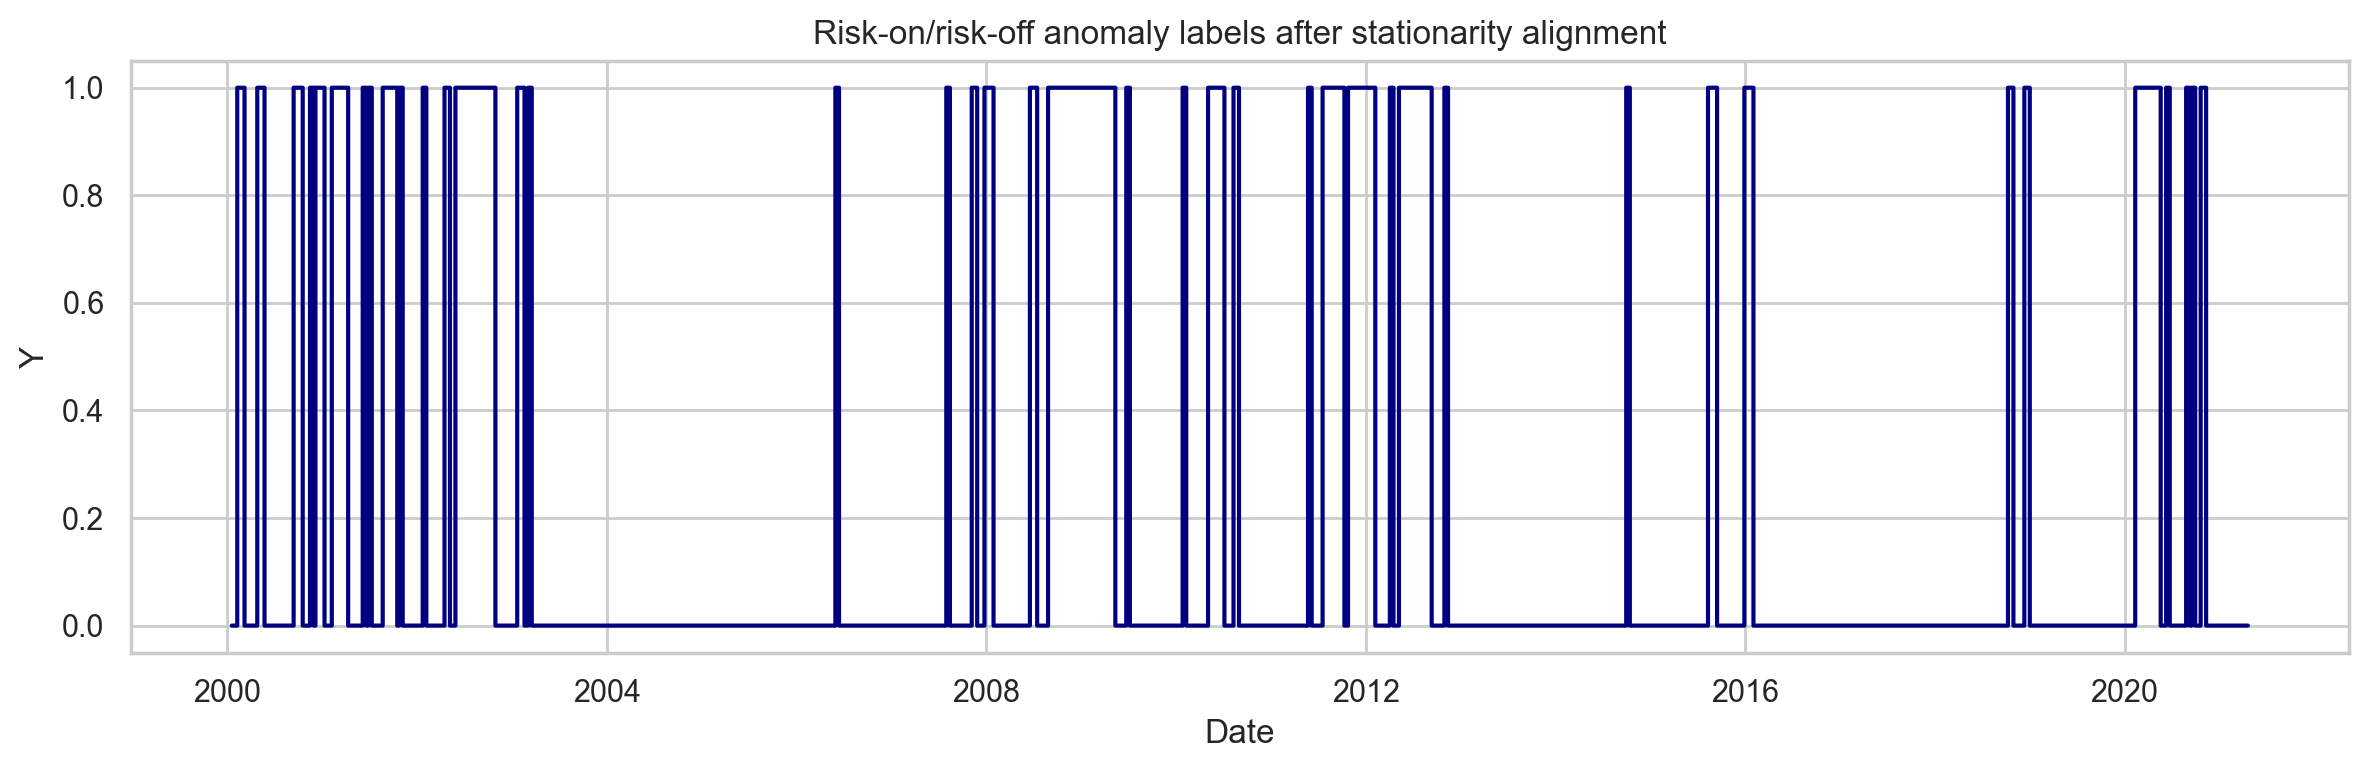

In [89]:
# Load the real BC4 EWS dataset and reproduce the original stationarity/split pipeline.
dataset_path = Path("BC4/Dataset4_EWS.xlsx")
if not dataset_path.exists():
    dataset_path = Path("Dataset4_EWS.xlsx")
if not dataset_path.exists():
    raise FileNotFoundError("Could not find Dataset4_EWS.xlsx in BC4/ or the current directory.")

data_df = pd.read_excel(dataset_path, sheet_name="Markets")
metadata_df = pd.read_excel(dataset_path, sheet_name="Metadata")

date_col = "Date" if "Date" in data_df.columns else data_df.columns[0]
y_col = "Y" if "Y" in data_df.columns else None
if y_col is None:
    raise ValueError("Expected an anomaly label column named 'Y' in the Markets sheet.")

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
data_df = data_df.set_index(date_col).sort_index()

X_df = data_df.drop(columns=[y_col])
y_raw = data_df[y_col].astype(int).values

indices_currencies = [col for col in X_df.columns if col in [
    "XAUBGNL", "BDIY", "CRY", "Cl1", "DXY", "EMUSTRUU", "GBP", "JPY", "LF94TRUU",
    "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU", "LUACTRUU", "LUMSTRUU",
    "MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "VIX"
]]

interest_rates = [col for col in X_df.columns if col in [
    "EONIA", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y", "GTGBP30Y",
    "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR", "GTJPY2YR", "GTJPY30YR",
    "US0001M", "USGG3M", "USGG2YR", "GT10", "USGG30YR"
]]

stationary_df = pd.DataFrame(index=X_df.index[1:])

for col in indices_currencies:
    stationary_df[col] = np.diff(np.log(X_df[col].astype(float)))

for col in interest_rates:
    stationary_df[col] = np.diff(X_df[col].astype(float))

if "ECSURPUS" in X_df.columns:
    stationary_df["ECSURPUS"] = X_df["ECSURPUS"].astype(float).values[1:]

y_stationary = y_raw[1:]
stationary_df = stationary_df.replace([np.inf, -np.inf], np.nan)
valid_mask = stationary_df.notna().all(axis=1)
stationary_df = stationary_df.loc[valid_mask]
y_stationary = y_stationary[valid_mask.to_numpy()].astype(int)
feature_names = stationary_df.columns.to_list()

X = stationary_df.values
y = y_stationary
dates = stationary_df.index.to_numpy()  # preserved through shuffle for the backtest

X_shuffled, y_shuffled, dates_shuffled = shuffle(X, y, dates, random_state=SEED)
normal_mask = y_shuffled == 0
anomaly_mask = y_shuffled == 1
X_normal, dates_normal = X_shuffled[normal_mask], dates_shuffled[normal_mask]
X_anomaly, dates_anomaly = X_shuffled[anomaly_mask], dates_shuffled[anomaly_mask]

n_normal = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]
if n_normal == 0 or n_anomaly < 2:
    raise ValueError("Need normal observations and at least two anomalies for the train/CV/test split.")

train_size = int(0.8 * n_normal)
cv_normal_size = int(0.1 * n_normal)
cv_anomaly_size = max(1, int(0.5 * n_anomaly))

X_train_raw = X_normal[:train_size]
X_cv_normal = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly = X_anomaly[:cv_anomaly_size]
X_cross_val_raw = np.vstack([X_cv_normal, X_cv_anomaly])
y_cross_val = np.hstack([np.zeros(len(X_cv_normal)), np.ones(len(X_cv_anomaly))]).astype(int)

X_test_normal = X_normal[train_size + cv_normal_size:]
X_test_anomaly = X_anomaly[cv_anomaly_size:]
X_test_raw = np.vstack([X_test_normal, X_test_anomaly])
y_test = np.hstack([np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))]).astype(int)

test_dates_normal = dates_normal[train_size + cv_normal_size:]
test_dates_anomaly = dates_anomaly[cv_anomaly_size:]
test_dates = np.concatenate([test_dates_normal, test_dates_anomaly])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_cross_val = scaler.transform(X_cross_val_raw)
X_test = scaler.transform(X_test_raw)

print(f"Dataset path: {dataset_path}")
print(f"Stationary feature matrix: {stationary_df.shape[0]} observations x {stationary_df.shape[1]} features")
print(f"Total anomalies after stationarity/dropna: {int(y.sum())} ({y.mean() * 100:.2f}%)")
print(f"Training set: {X_train.shape[0]} normal observations")
print(f"Cross-validation set: {X_cross_val.shape[0]} observations ({len(X_cv_normal)} normal, {len(X_cv_anomaly)} anomalies)")
print(f"Test set: {X_test.shape[0]} observations ({len(X_test_normal)} normal, {len(X_test_anomaly)} anomalies)")
print(f"Anomaly base rate on test set: {y_test.mean() * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(stationary_df.index, y_stationary, drawstyle="steps-post", color="navy")
plt.title("Risk-on/risk-off anomaly labels after stationarity alignment")
plt.xlabel("Date")
plt.ylabel("Y")
plt.tight_layout()
plt.show()


## 2. Define the GAN

The discriminator returns a **logit**, not a probability. During training we use `BCEWithLogitsLoss`, which is numerically more stable than applying a sigmoid first. During scoring we convert logits to probabilities with `torch.sigmoid`.

The generator maps a latent noise vector `z` into a synthetic normal market sample.

In [90]:
# GAN architecture
input_dim = X_train.shape[1]
latent_dim = min(16, max(4, input_dim // 4))
hidden_dim = min(128, max(32, input_dim * 2))
batch_size = min(128, max(16, len(X_train) // 10))

train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self, latent_dim: int, output_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

G = Generator(latent_dim, input_dim, hidden_dim).to(device)
D = Discriminator(input_dim, hidden_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
g_optimizer = optim.Adam(G.parameters(), lr=1e-3, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=1e-3, betas=(0.5, 0.999))

print(f"Input dimension: {input_dim} | latent: {latent_dim} | hidden: {hidden_dim} | batch: {batch_size}")
print(G)
print(D)


Input dimension: 42 | latent: 10 | hidden: 84 | batch: 69
Generator(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=84, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=84, out_features=84, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=84, out_features=42, bias=True)
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=84, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=84, out_features=84, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=84, out_features=1, bias=True)
  )
)


## 3. Train on normal market samples only

The discriminator sees:

- real normal observations from the training set
- generated normal-like observations from the generator

The generator learns to produce samples that the discriminator classifies as real normal data.

Epoch 001 | D loss=1.3687 | G loss=0.6253
Epoch 050 | D loss=1.3913 | G loss=0.7237
Epoch 100 | D loss=1.3895 | G loss=0.6880
Epoch 150 | D loss=1.3751 | G loss=0.6915
Epoch 200 | D loss=1.3804 | G loss=0.7098
Epoch 250 | D loss=1.3520 | G loss=0.6839
Epoch 300 | D loss=1.3714 | G loss=0.7200


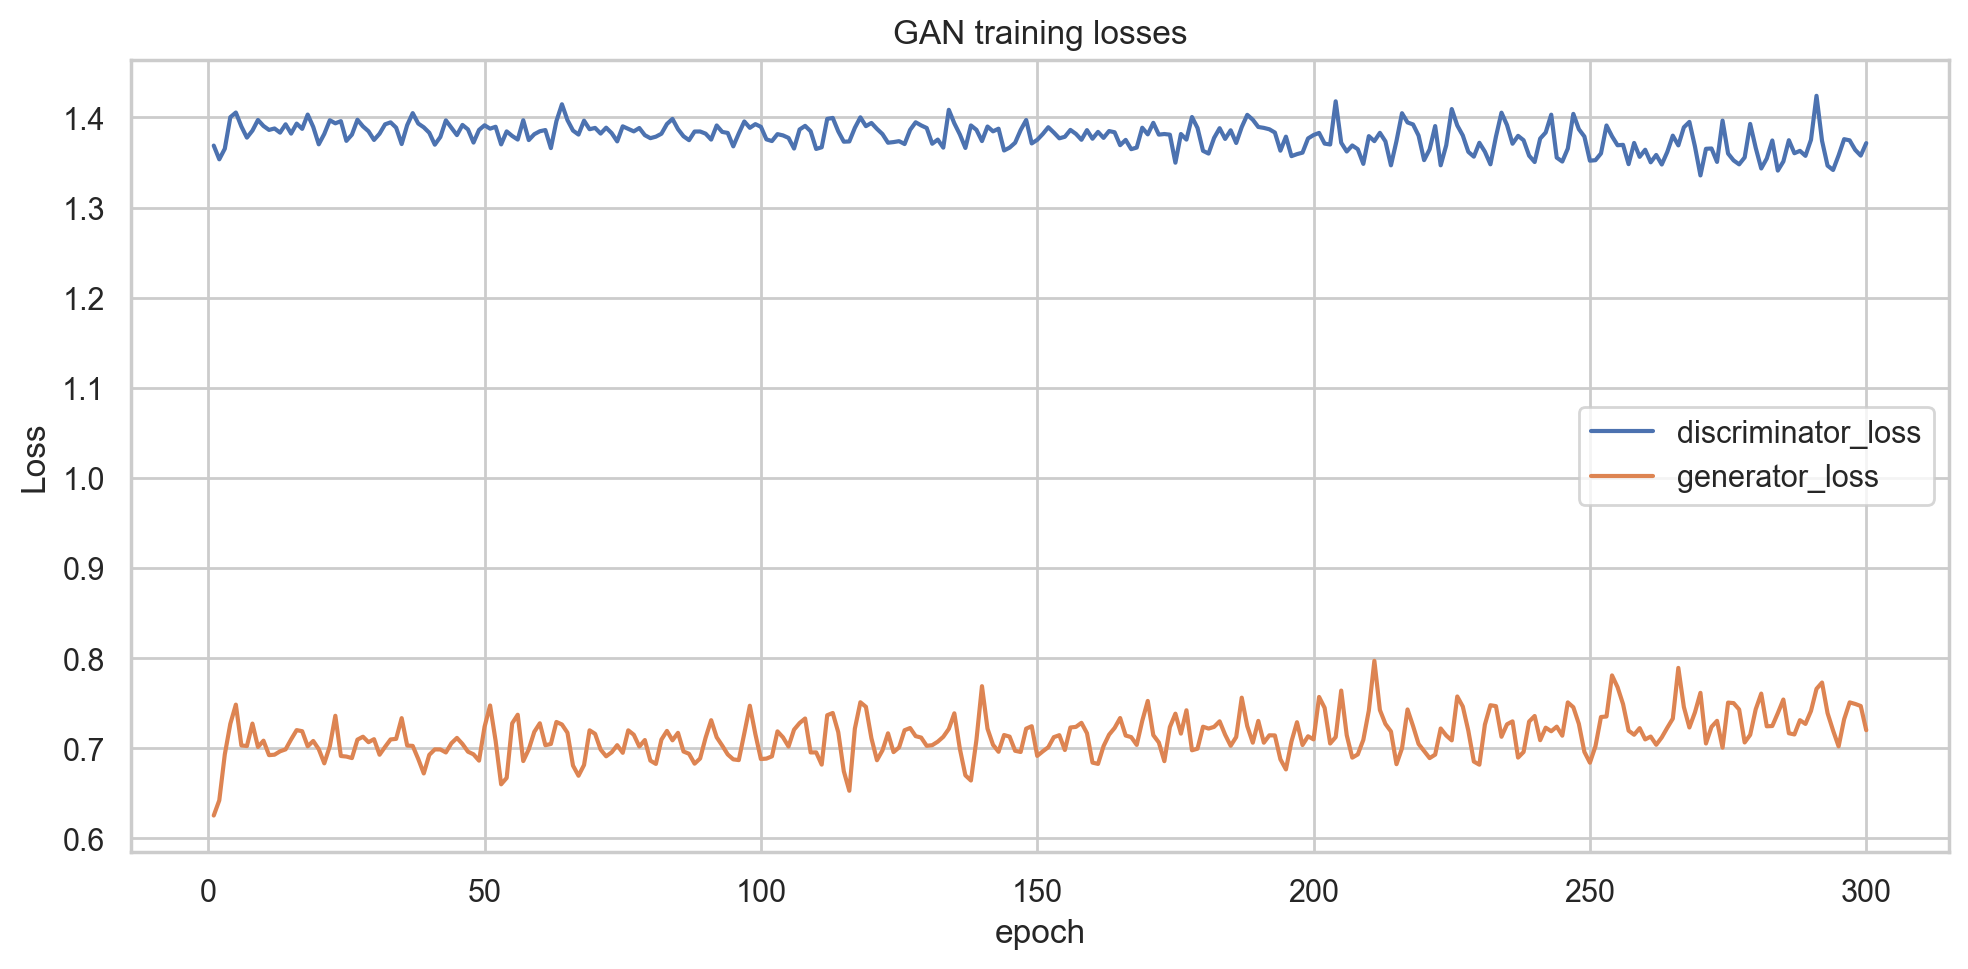

In [91]:
def train_gan(generator, discriminator, loader, epochs=300, print_every=50):
    history = []
    generator.train()
    discriminator.train()

    for epoch in range(1, epochs + 1):
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0

        for (real_batch,) in loader:
            real_batch = real_batch.to(device)
            current_batch_size = real_batch.size(0)

            real_labels = torch.ones(current_batch_size, device=device)
            fake_labels = torch.zeros(current_batch_size, device=device)

            # 1. Train discriminator: real normal samples should be real, generated samples should be fake.
            z = torch.randn(current_batch_size, latent_dim, device=device)
            fake_batch = generator(z).detach()

            d_optimizer.zero_grad()
            real_logits = discriminator(real_batch)
            fake_logits = discriminator(fake_batch)
            d_loss = criterion(real_logits, real_labels) + criterion(fake_logits, fake_labels)
            d_loss.backward()
            d_optimizer.step()

            # 2. Train generator: generated samples should look real to the discriminator.
            z = torch.randn(current_batch_size, latent_dim, device=device)
            g_optimizer.zero_grad()
            generated_batch = generator(z)
            generated_logits = discriminator(generated_batch)
            g_loss = criterion(generated_logits, real_labels)
            g_loss.backward()
            g_optimizer.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(loader)
        avg_g_loss = epoch_g_loss / len(loader)
        history.append({"epoch": epoch, "discriminator_loss": avg_d_loss, "generator_loss": avg_g_loss})

        if epoch == 1 or epoch % print_every == 0:
            print(f"Epoch {epoch:03d} | D loss={avg_d_loss:.4f} | G loss={avg_g_loss:.4f}")

    return pd.DataFrame(history)

history = train_gan(G, D, train_loader, epochs=300, print_every=50)

history.plot(x="epoch", y=["discriminator_loss", "generator_loss"], figsize=(10, 5))
plt.title("GAN training losses")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

## 4. Score anomalies with discriminator realism

The discriminator anomaly score is `1 - D_prob(x)`. The risk-on/risk-off decision is:

$$
\text{Defensive reallocation} \Longleftrightarrow 1 - D_{prob}(x) > \varepsilon
$$

Threshold selection is **F-beta with beta = 1.5 subject to a precision floor** of
`min(0.7, base_rate + 0.25)`. Two safeguards matter on imbalanced labels:

- The floor demands a real **lift over baseline** (at least +25pp of precision) rather
  than a fixed absolute number, because the CV set has a much higher anomaly rate than
  the underlying market and a fixed 0.3 floor would barely bind.
- If no threshold meets the floor, the detector is declared **unfit to fire**: we set
  `epsilon` above the score maximum so no row is ever flagged. Better to stay in the
  market than deploy a model that fires indiscriminately.


In [92]:
def discriminator_anomaly_score(discriminator, X):
    """Return 1 - D(x): higher means the observation looks less like real normal data."""
    discriminator.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        logits = discriminator(X_tensor)
        probabilities = torch.sigmoid(logits).cpu().numpy()
    return 1.0 - probabilities


RISK_BETA = 1.5  # recall ~2.25x precision in F-beta; less aggressive than F2.


def choose_anomaly_threshold(y_true, anomaly_score, beta=RISK_BETA, precision_floor=None, n_grid=1000):
    """Maximise F-beta on the CV set subject to precision >= floor.

    Default floor = min(0.7, base_rate + 0.25). Demanding a fixed lift over baseline
    blocks the degenerate "fire on everything" attractor whose precision otherwise
    sits at base rate. If no threshold passes the floor, the detector is declared
    unfit to fire (epsilon set above the score maximum), so it stays passive rather
    than triggering on every observation.
    """
    base_rate = float(np.mean(y_true))
    if precision_floor is None:
        precision_floor = float(min(0.7, base_rate + 0.25))

    thresholds = np.linspace(anomaly_score.min(), anomaly_score.max(), n_grid)
    best = None
    for epsilon in thresholds:
        pred = (anomaly_score > epsilon).astype(int)
        precision = precision_score(y_true, pred, zero_division=0)
        if precision < precision_floor:
            continue
        fbeta = fbeta_score(y_true, pred, beta=beta, zero_division=0)
        if best is None or fbeta > best["fbeta"]:
            best = {
                "epsilon": float(epsilon),
                "fbeta": float(fbeta),
                "f1": float(f1_score(y_true, pred, zero_division=0)),
                "precision": float(precision),
                "recall": float(recall_score(y_true, pred, zero_division=0)),
            }

    if best is None:
        # No threshold met the floor -> detector is unfit. Set epsilon above the
        # score maximum so the model never fires; the user gets a clear "never_fires"
        # flag to surface this in the comparison table.
        best = {
            "epsilon": float(anomaly_score.max() + 1.0),
            "fbeta": 0.0,
            "f1": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "never_fires": True,
        }
    else:
        best["never_fires"] = False

    best["precision_floor"] = precision_floor
    best["base_rate"] = base_rate
    best["lift"] = best["precision"] / base_rate if base_rate > 0 else 0.0
    return best


cv_realism = discriminator_anomaly_score(D, X_cross_val)
test_realism = discriminator_anomaly_score(D, X_test)

realism_threshold = choose_anomaly_threshold(y_cross_val, cv_realism)
y_pred_realism = (test_realism > realism_threshold["epsilon"]).astype(int)

realism_threshold


{'epsilon': 0.5431523323059082,
 'fbeta': 0.38235294117647056,
 'f1': 0.4431137724550898,
 'precision': 0.7551020408163265,
 'recall': 0.3135593220338983,
 'never_fires': False,
 'precision_floor': 0.7,
 'base_rate': 0.5756097560975609,
 'lift': 1.3118298166724316}

## 5. Score anomalies with GAN reconstruction

A plain GAN has no encoder, so we cannot directly map an input `x` into a latent vector. For reconstruction scoring, we search for the latent vector `z*` whose generated sample is closest to `x`:

$$
z^* = \arg\min_z \|x - G(z)\|^2
$$

Then the anomaly score is the reconstruction error:

$$
\text{Anomaly} \Longleftrightarrow \|x - G(z^*)\|^2 > \varepsilon
$$

This is slower than discriminator scoring, but it is closer to the Autoencoder logic used in the original notebook.

In [93]:
def gan_reconstruction_error(generator, X, latent_dim, steps=250, lr=0.05, batch_size=128):
    """Optimise z to reconstruct each batch, then return per-sample reconstruction MSE."""
    generator.eval()
    errors = []

    for start in range(0, len(X), batch_size):
        batch_np = X[start:start + batch_size]
        x = torch.tensor(batch_np, dtype=torch.float32, device=device)
        z = torch.randn(x.size(0), latent_dim, device=device, requires_grad=True)
        z_optimizer = optim.Adam([z], lr=lr)

        for _ in range(steps):
            z_optimizer.zero_grad()
            reconstructed = generator(z)
            # Per-sample MSE summed across the batch keeps each row's gradient independent of batch size.
            loss = ((reconstructed - x) ** 2).mean(dim=1).sum()
            loss.backward()
            z_optimizer.step()

        with torch.no_grad():
            reconstructed = generator(z)
            batch_errors = ((reconstructed - x) ** 2).mean(dim=1).cpu().numpy()
            errors.extend(batch_errors)

    return np.array(errors)


cv_reconstruction_error = gan_reconstruction_error(G, X_cross_val, latent_dim, steps=250)
test_reconstruction_error = gan_reconstruction_error(G, X_test, latent_dim, steps=250)

reconstruction_threshold = choose_anomaly_threshold(y_cross_val, cv_reconstruction_error)
y_pred_reconstruction = (test_reconstruction_error > reconstruction_threshold["epsilon"]).astype(int)

reconstruction_threshold


{'epsilon': 0.4047442078590393,
 'fbeta': 0.7540983606557377,
 'f1': 0.7389558232931727,
 'precision': 0.7022900763358778,
 'recall': 0.7796610169491526,
 'never_fires': False,
 'precision_floor': 0.7,
 'base_rate': 0.5756097560975609,
 'lift': 1.2200802173631777}

## 6. Evaluate the two GAN anomaly scores

Headline metrics for the risk-management user:

- **Recall** -- fraction of real anomalies the model would catch.
- **F2** -- the threshold-selection objective itself.
- **False-negative rate (FNR)** -- missed crises per real crisis.
- **PR-AUC** (average precision) -- threshold-free summary that is more meaningful than
  ROC-AUC under heavy class imbalance.
- Precision, F1, ROC-AUC are reported for completeness but are not the primary lens.



GAN discriminator realism score
Recall:       0.3193   <- crises caught
FNR:          0.6807   <- crises missed (lower is better)
F2:           0.3532
PR-AUC:       0.6105  (baseline = 0.5749)
Precision:    0.6129
F1:           0.4199
ROC-AUC:      0.4490


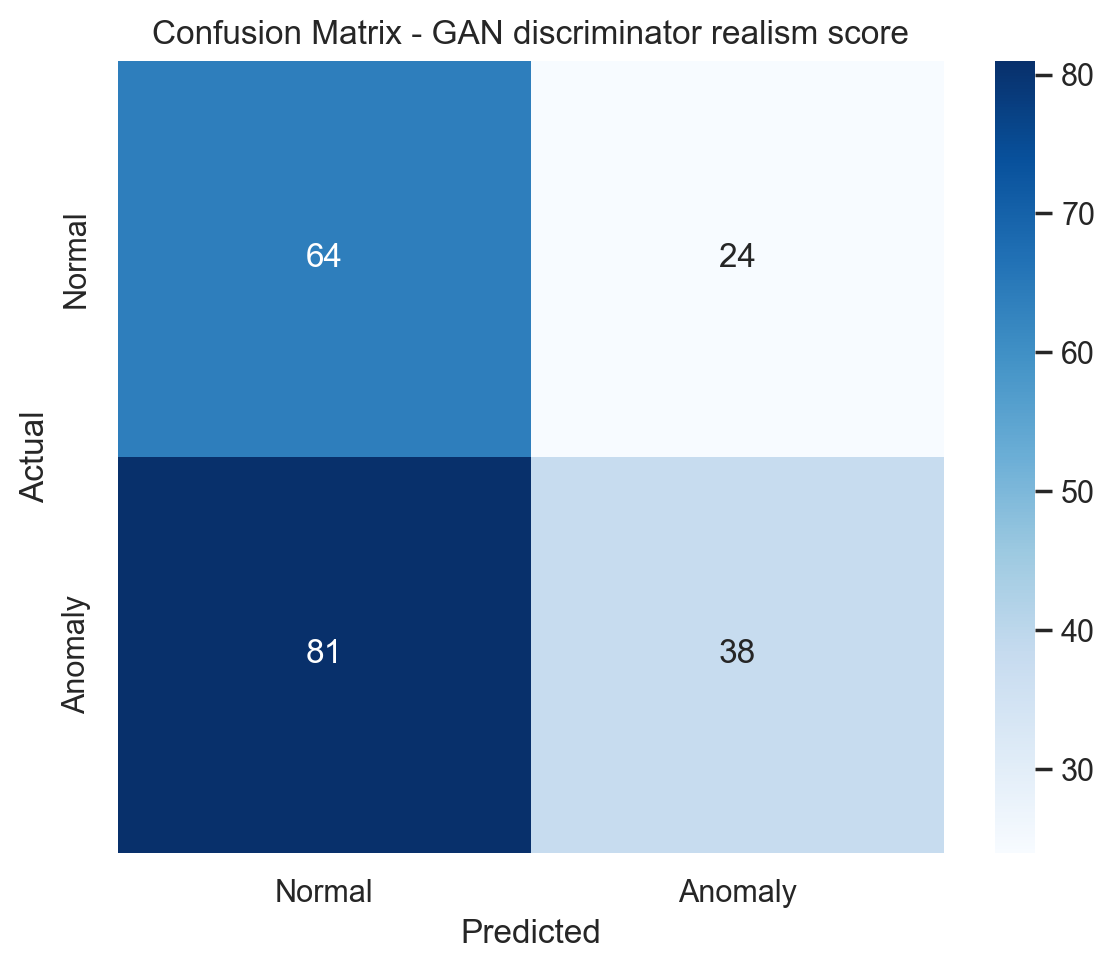

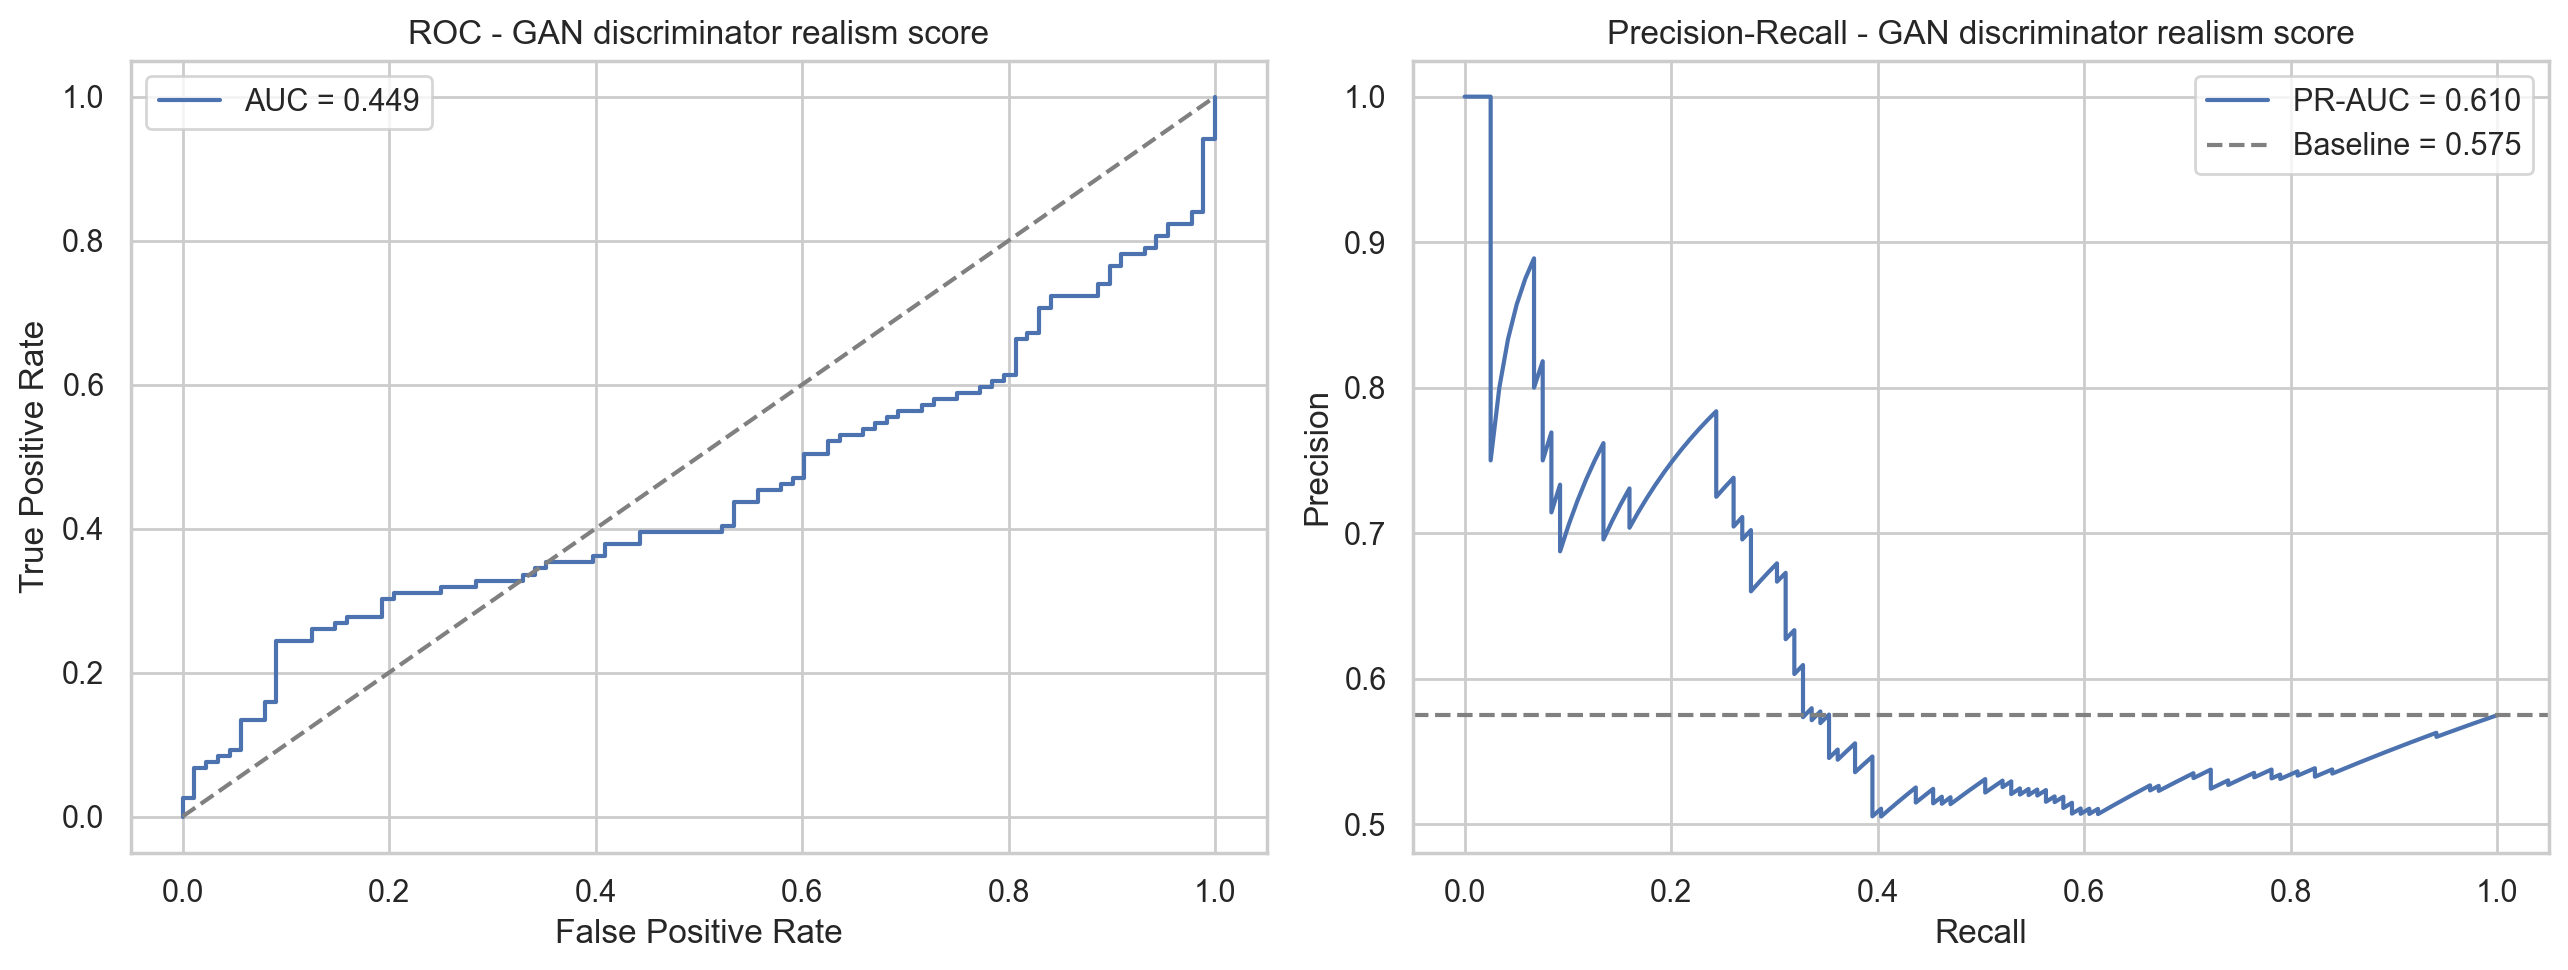


GAN reconstruction score
Recall:       0.7395   <- crises caught
FNR:          0.2605   <- crises missed (lower is better)
F2:           0.7261
PR-AUC:       0.7965  (baseline = 0.5749)
Precision:    0.6769
F1:           0.7068
ROC-AUC:      0.7276


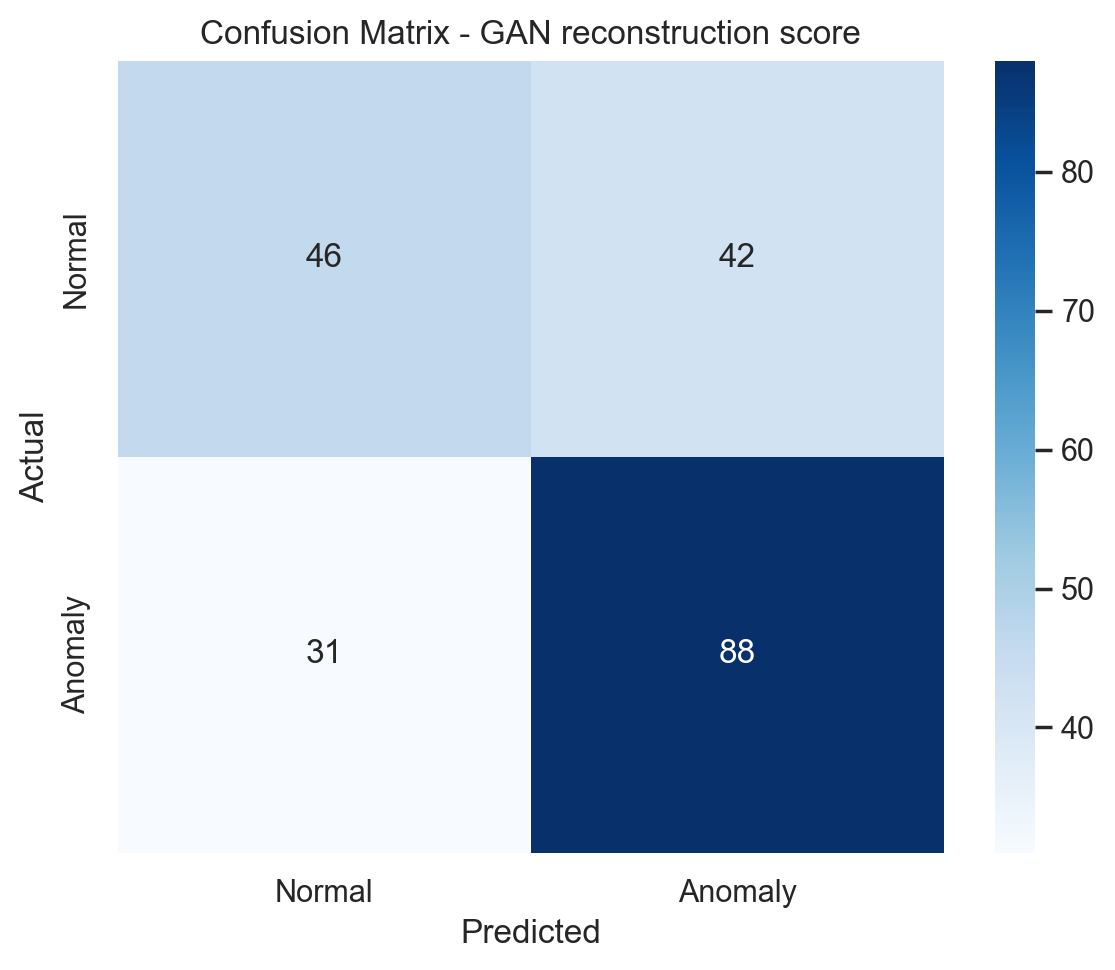

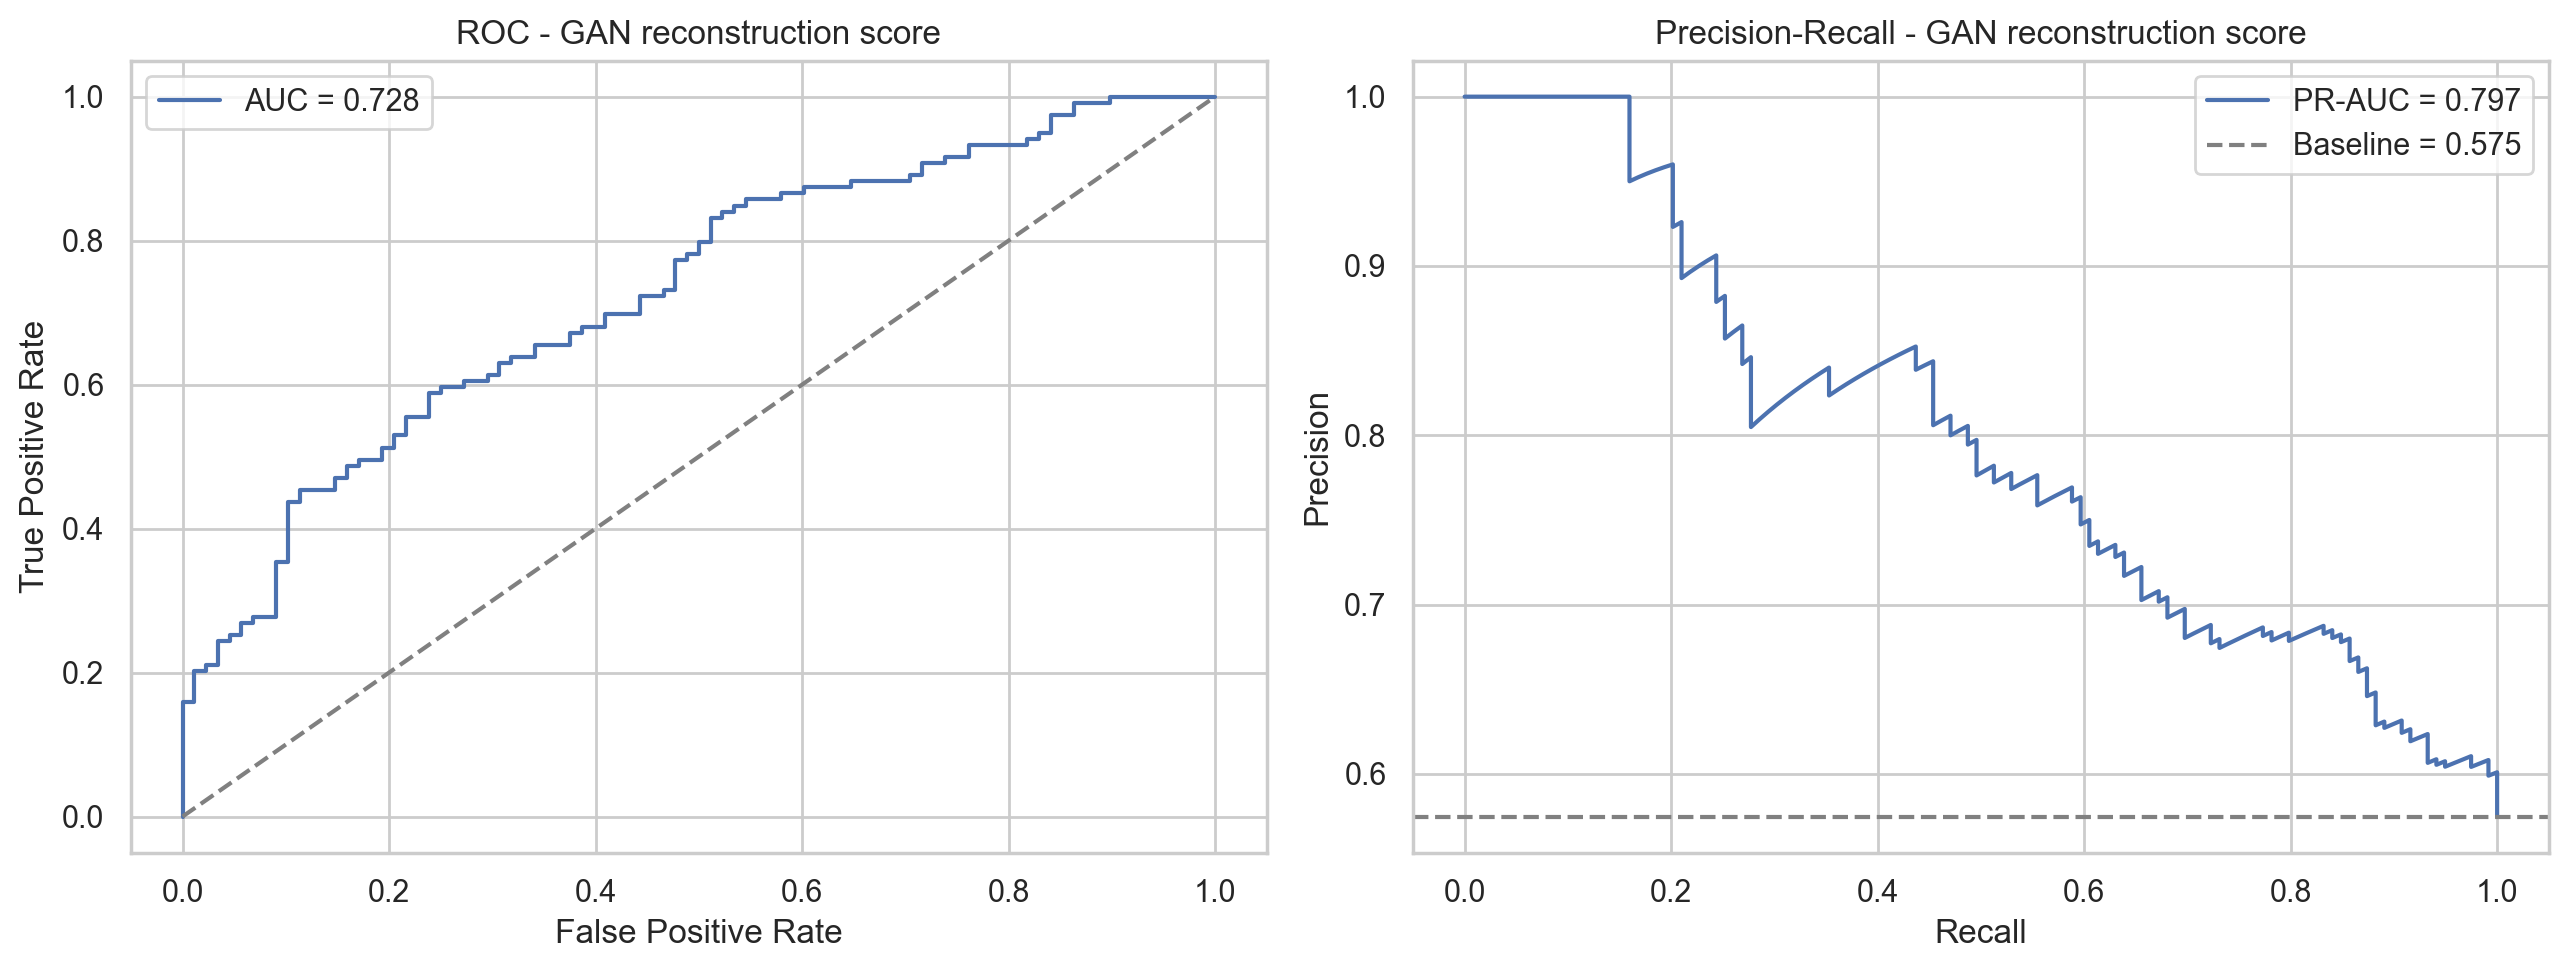

,model,precision,recall,f1,f2,fnr,roc_auc,pr_auc
0,GAN discriminator realism score,0.612903,0.319328,0.419890,0.353160,0.680672,0.449007,0.610470
1,GAN reconstruction score,0.676923,0.739496,0.706827,0.726073,0.260504,0.727559,0.796536


In [94]:
def evaluate_anomaly_detector(y_true, y_pred, anomaly_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2.0, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, anomaly_score)
    roc_auc = auc(fpr, tpr)
    pr_precision, pr_recall, _ = precision_recall_curve(y_true, anomaly_score)
    pr_auc = average_precision_score(y_true, anomaly_score)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    baseline_rate = float(np.mean(y_true))

    print(f"\n{model_name}")
    print(f"Recall:       {recall:.4f}   <- crises caught")
    print(f"FNR:          {fnr:.4f}   <- crises missed (lower is better)")
    print(f"F2:           {f2:.4f}")
    print(f"PR-AUC:       {pr_auc:.4f}  (baseline = {baseline_rate:.4f})")
    print(f"Precision:    {precision:.4f}")
    print(f"F1:           {f1:.4f}")
    print(f"ROC-AUC:      {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Anomaly"],
                yticklabels=["Normal", "Anomaly"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC - {model_name}")
    axes[0].legend()

    axes[1].plot(pr_recall, pr_precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(baseline_rate, color="gray", linestyle="--", label=f"Baseline = {baseline_rate:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall - {model_name}")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "fnr": fnr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }


realism_metrics = evaluate_anomaly_detector(
    y_test, y_pred_realism, test_realism, "GAN discriminator realism score",
)

reconstruction_metrics = evaluate_anomaly_detector(
    y_test, y_pred_reconstruction, test_reconstruction_error, "GAN reconstruction score",
)

pd.DataFrame([realism_metrics, reconstruction_metrics])


## 7. VAE anomaly detection

A Variational Autoencoder gives a second deep-learning baseline with a different inductive bias from the GAN.

The VAE learns:

- an **encoder** that maps a market observation into a latent Gaussian distribution
- a **decoder** that reconstructs the observation from a sampled latent vector
- a regularized latent space through the KL-divergence term

As with the GAN, the VAE is trained on **normal observations only**. At inference time, observations with high reconstruction error are treated as anomalous:

$$
\text{Anomaly} \Longleftrightarrow \|x - \hat{x}\|^2 > \varepsilon
$$

The threshold is selected on the same cross-validation set used for the GAN scores.

VAE latent: 10 | hidden: 84
Epoch 001 | VAE loss=42.0993 | recon=42.0306 | KL=0.0687
Epoch 050 | VAE loss=27.4756 | recon=23.1169 | KL=4.3586
Epoch 100 | VAE loss=26.4243 | recon=21.3397 | KL=5.0846
Epoch 150 | VAE loss=24.8855 | recon=19.4792 | KL=5.4063
Epoch 200 | VAE loss=24.4313 | recon=18.9322 | KL=5.4992
Epoch 250 | VAE loss=23.8375 | recon=18.2341 | KL=5.6034


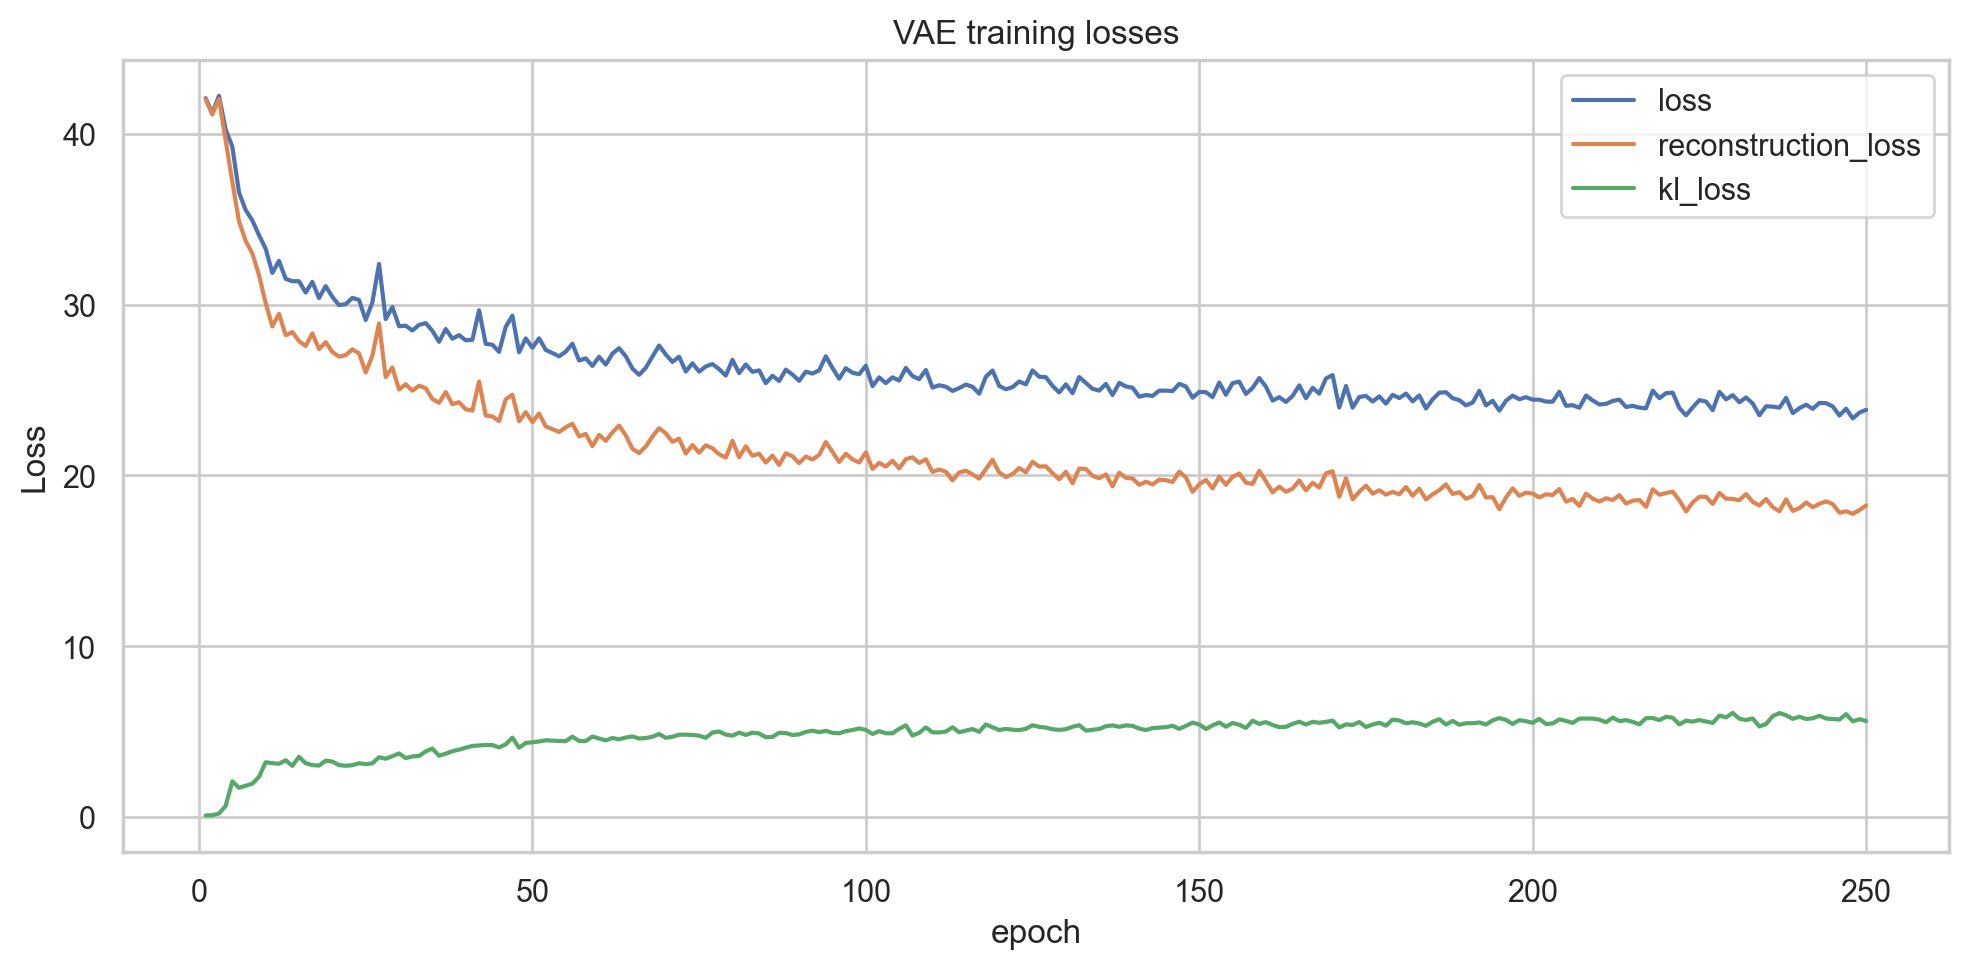


VAE reconstruction score
Recall:       0.8067   <- crises caught
FNR:          0.1933   <- crises missed (lower is better)
F2:           0.7754
PR-AUC:       0.7951  (baseline = 0.5749)
Precision:    0.6713
F1:           0.7328
ROC-AUC:      0.7264


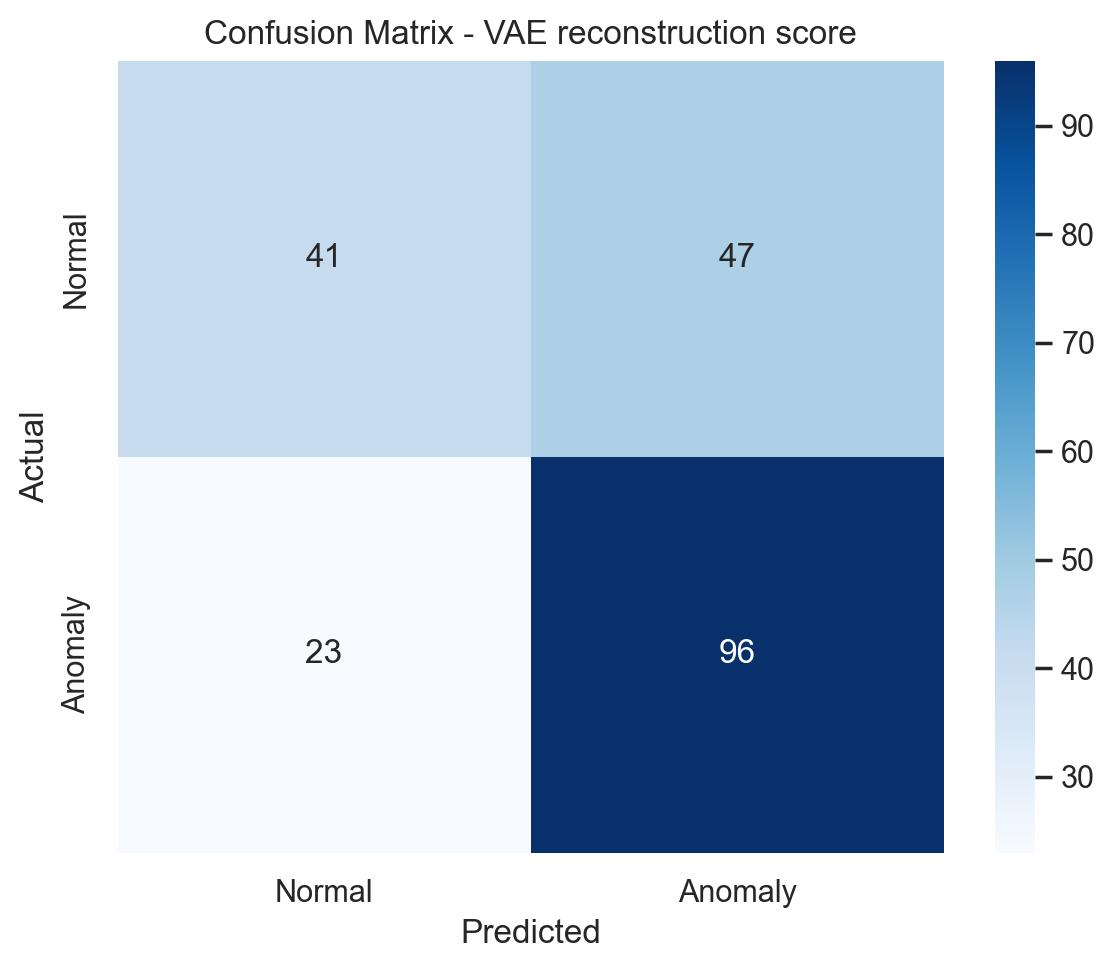

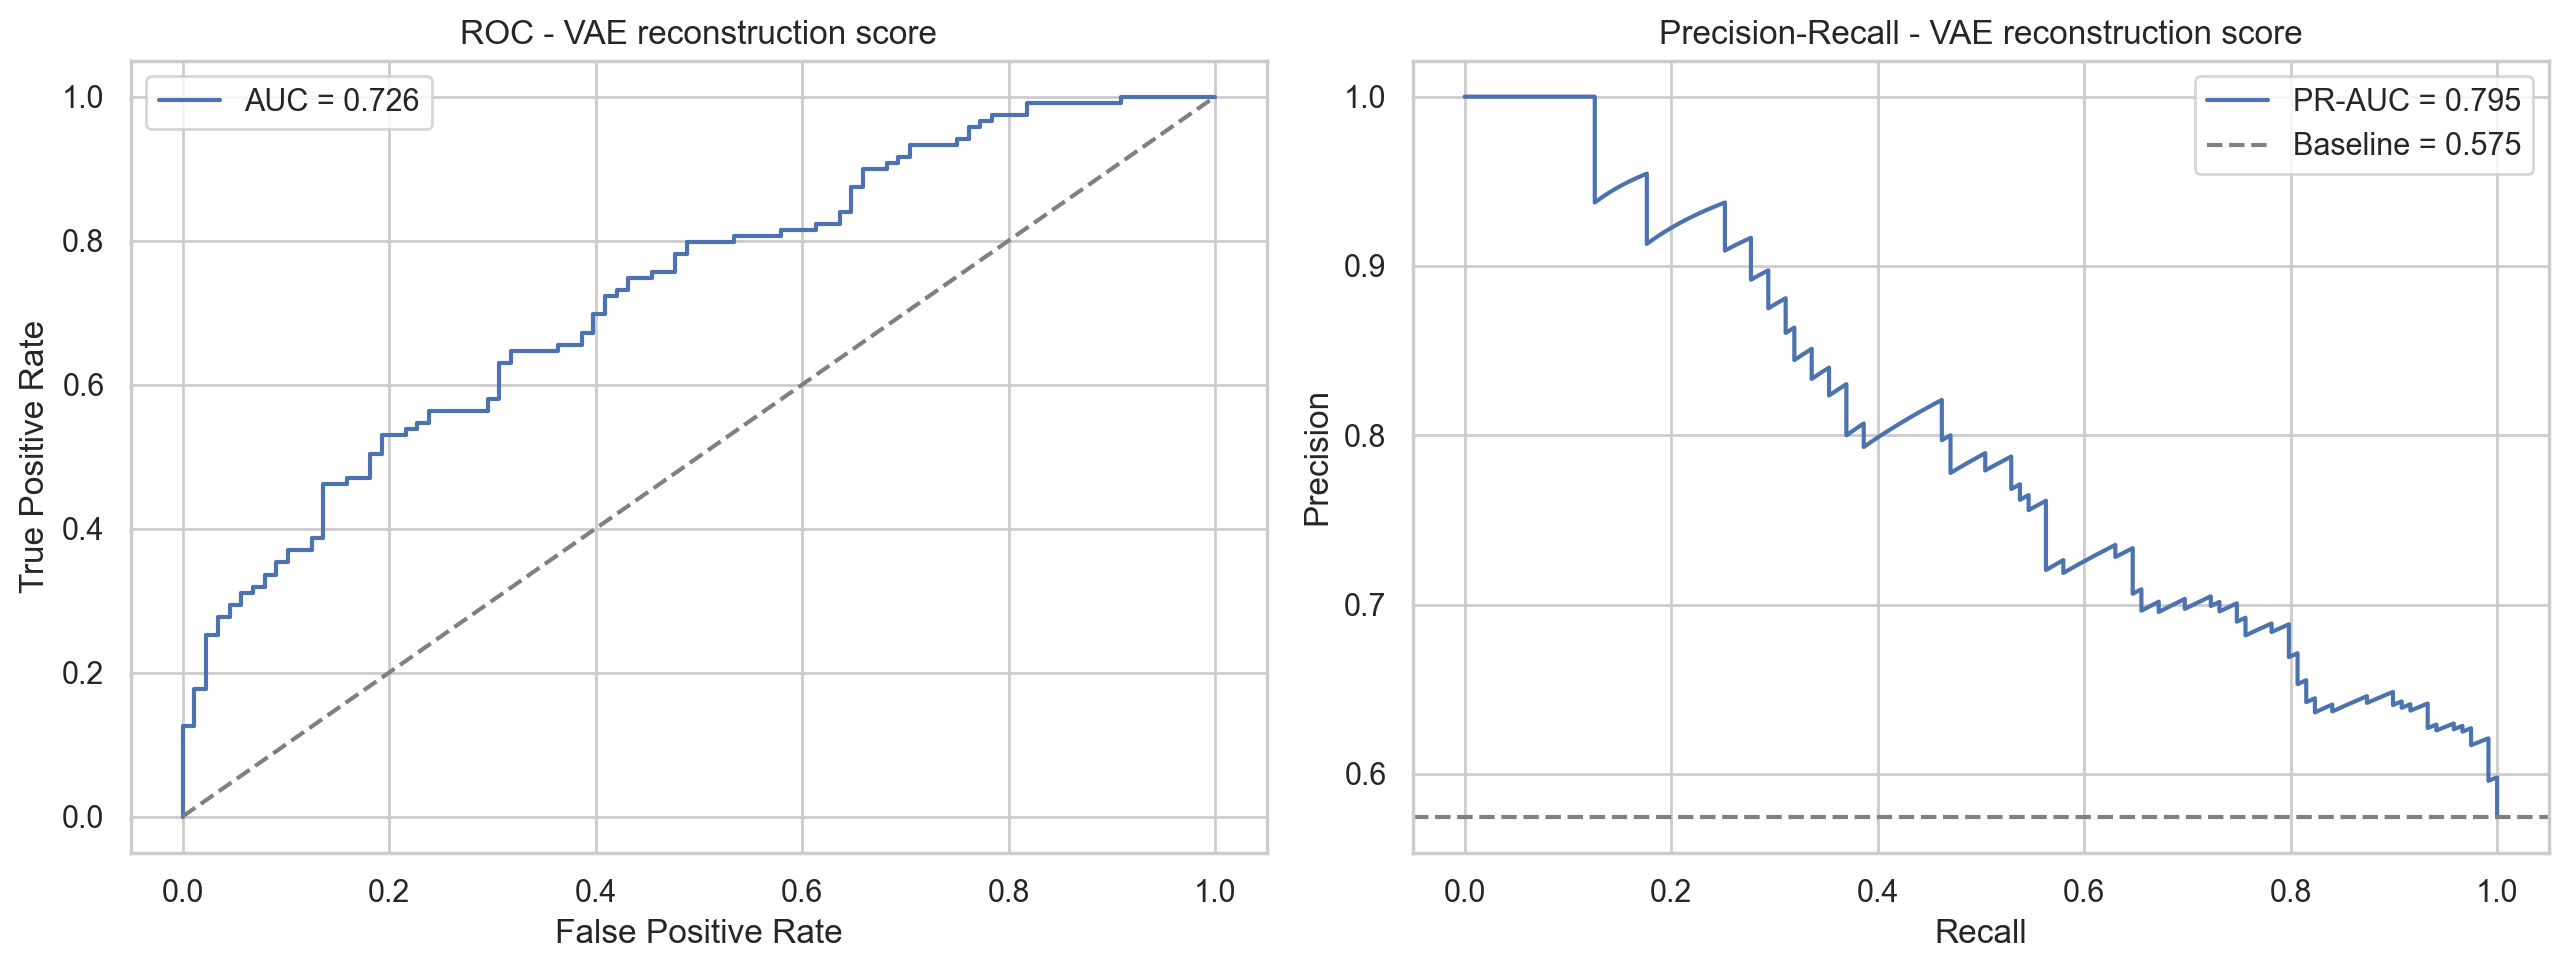

{'epsilon': 0.3751290440559387,
 'fbeta': 0.7932752179327521,
 'f1': 0.7716535433070866,
 'precision': 0.7205882352941176,
 'recall': 0.8305084745762712,
 'never_fires': False,
 'precision_floor': 0.7,
 'base_rate': 0.5756097560975609,
 'lift': 1.2518693918245265}

In [95]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8, hidden_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        hidden = self.encoder(x)
        return self.mu_layer(hidden), self.logvar_layer(hidden)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar


def vae_loss(reconstruction, x, mu, logvar, beta=1.0):
    # Both terms are summed over the feature/latent dimension and averaged over the batch,
    # so beta acts on comparable per-sample magnitudes regardless of input_dim.
    reconstruction_loss = ((reconstruction - x) ** 2).sum(dim=1).mean()
    kl_loss = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()
    return reconstruction_loss + beta * kl_loss, reconstruction_loss, kl_loss


def train_vae(model, loader, epochs=250, beta=1.0, lr=1e-3, patience=30, print_every=50):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best_loss = float("inf")
    best_state = None
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_reconstruction = 0.0
        epoch_kl = 0.0

        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            reconstruction, mu, logvar = model(batch)
            loss, reconstruction_loss, kl_loss = vae_loss(reconstruction, batch, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_reconstruction += reconstruction_loss.item()
            epoch_kl += kl_loss.item()

        avg_loss = epoch_loss / len(loader)
        avg_reconstruction = epoch_reconstruction / len(loader)
        avg_kl = epoch_kl / len(loader)
        history.append({
            "epoch": epoch,
            "loss": avg_loss,
            "reconstruction_loss": avg_reconstruction,
            "kl_loss": avg_kl,
        })

        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:03d} | VAE loss={avg_loss:.4f} | "
                f"recon={avg_reconstruction:.4f} | KL={avg_kl:.4f}"
            )

        if stale_epochs >= patience:
            print(f"Early stopping at epoch {epoch}; best loss={best_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)


def vae_reconstruction_error(model, X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        mu, _ = model.encode(X_tensor)
        reconstruction = model.decode(mu)  # posterior mean -> deterministic, less noisy
        errors = ((reconstruction - X_tensor) ** 2).mean(dim=1).cpu().numpy()
    return errors


vae_latent_dim = min(16, max(4, input_dim // 4))
vae_hidden_dim = min(128, max(32, input_dim * 2))
vae_model = VAE(input_dim=input_dim, latent_dim=vae_latent_dim, hidden_dim=vae_hidden_dim).to(device)

print(f"VAE latent: {vae_latent_dim} | hidden: {vae_hidden_dim}")

vae_history = train_vae(vae_model, train_loader, epochs=250, beta=1.0, patience=30, print_every=50)

vae_history.plot(x="epoch", y=["loss", "reconstruction_loss", "kl_loss"], figsize=(10, 5))
plt.title("VAE training losses")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

cv_vae_error = vae_reconstruction_error(vae_model, X_cross_val)
test_vae_error = vae_reconstruction_error(vae_model, X_test)

vae_threshold = choose_anomaly_threshold(y_cross_val, cv_vae_error)
y_pred_vae = (test_vae_error > vae_threshold["epsilon"]).astype(int)

vae_metrics = evaluate_anomaly_detector(
    y_test, y_pred_vae, test_vae_error, "VAE reconstruction score",
)

vae_threshold


## 8. Compare GAN and VAE anomaly detection

For risk management we rank models by **F2** (the optimisation target), with PR-AUC as
a threshold-free tiebreaker. ROC is shown for continuity with the original notebook but
should not drive model selection on this imbalanced label.


,model,recall,f2,fnr,pr_auc,precision,f1,roc_auc
0,VAE reconstruction score,0.806723,0.775444,0.193277,0.795081,0.671329,0.732824,0.726413
1,GAN reconstruction score,0.739496,0.726073,0.260504,0.796536,0.676923,0.706827,0.727559
2,GAN discriminator realism score,0.319328,0.353160,0.680672,0.610470,0.612903,0.419890,0.449007


/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_90576/1637925318.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x=metric, y="model", ax=ax, palette="viridis")
/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_90576/1637925318.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x=metric, y="model", ax=ax, palette="viridis")
/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_90576/1637925318.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x=metric,

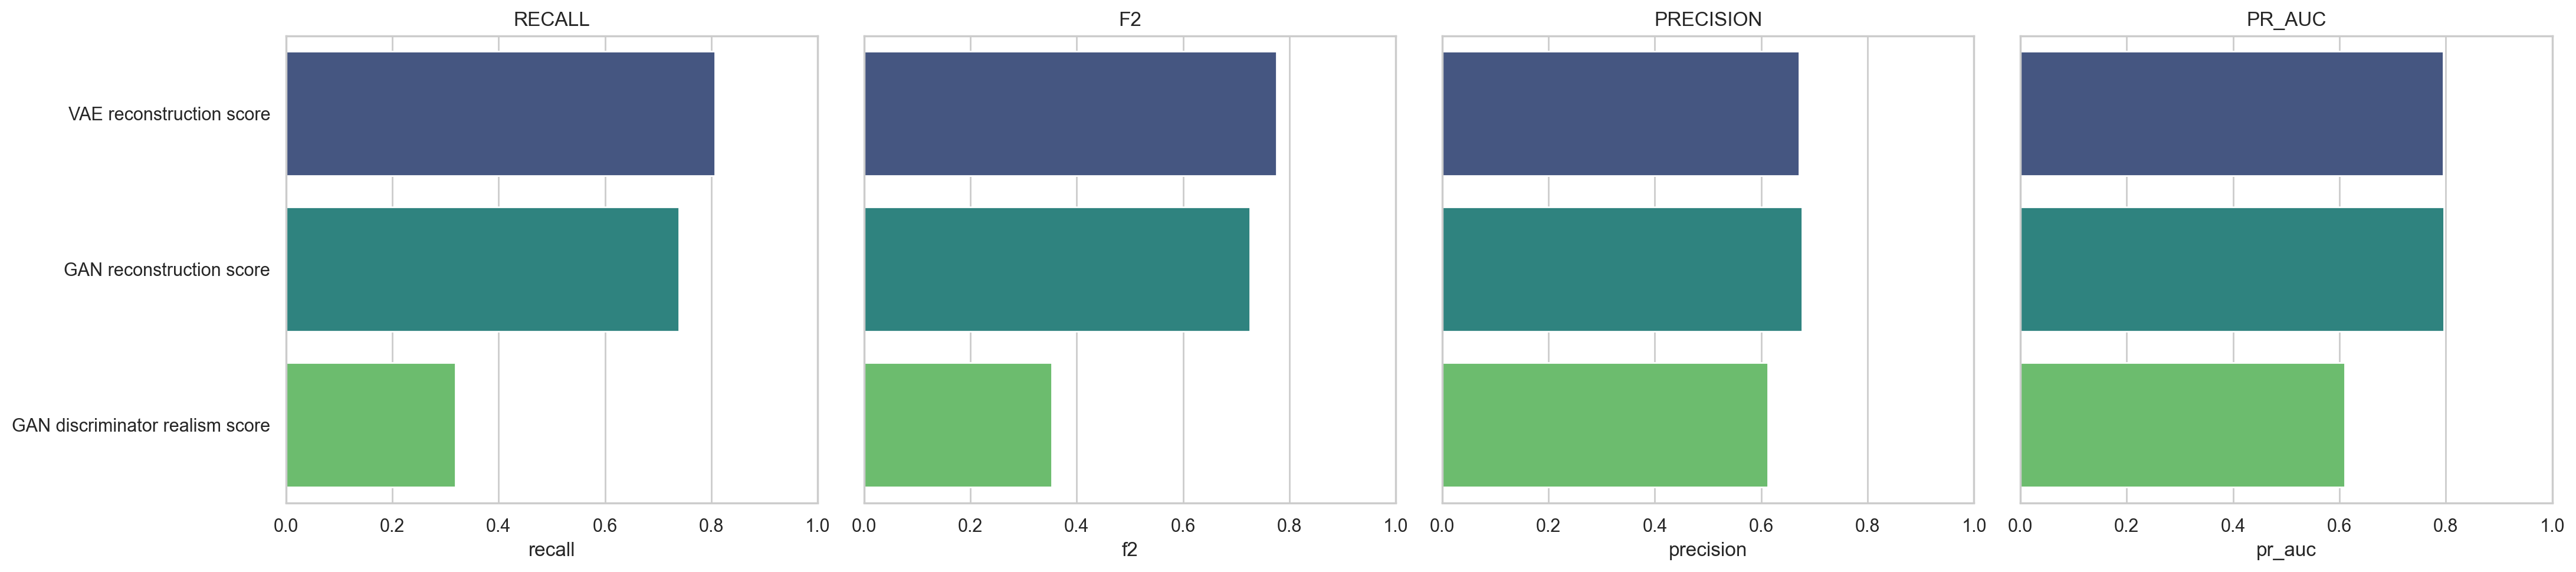

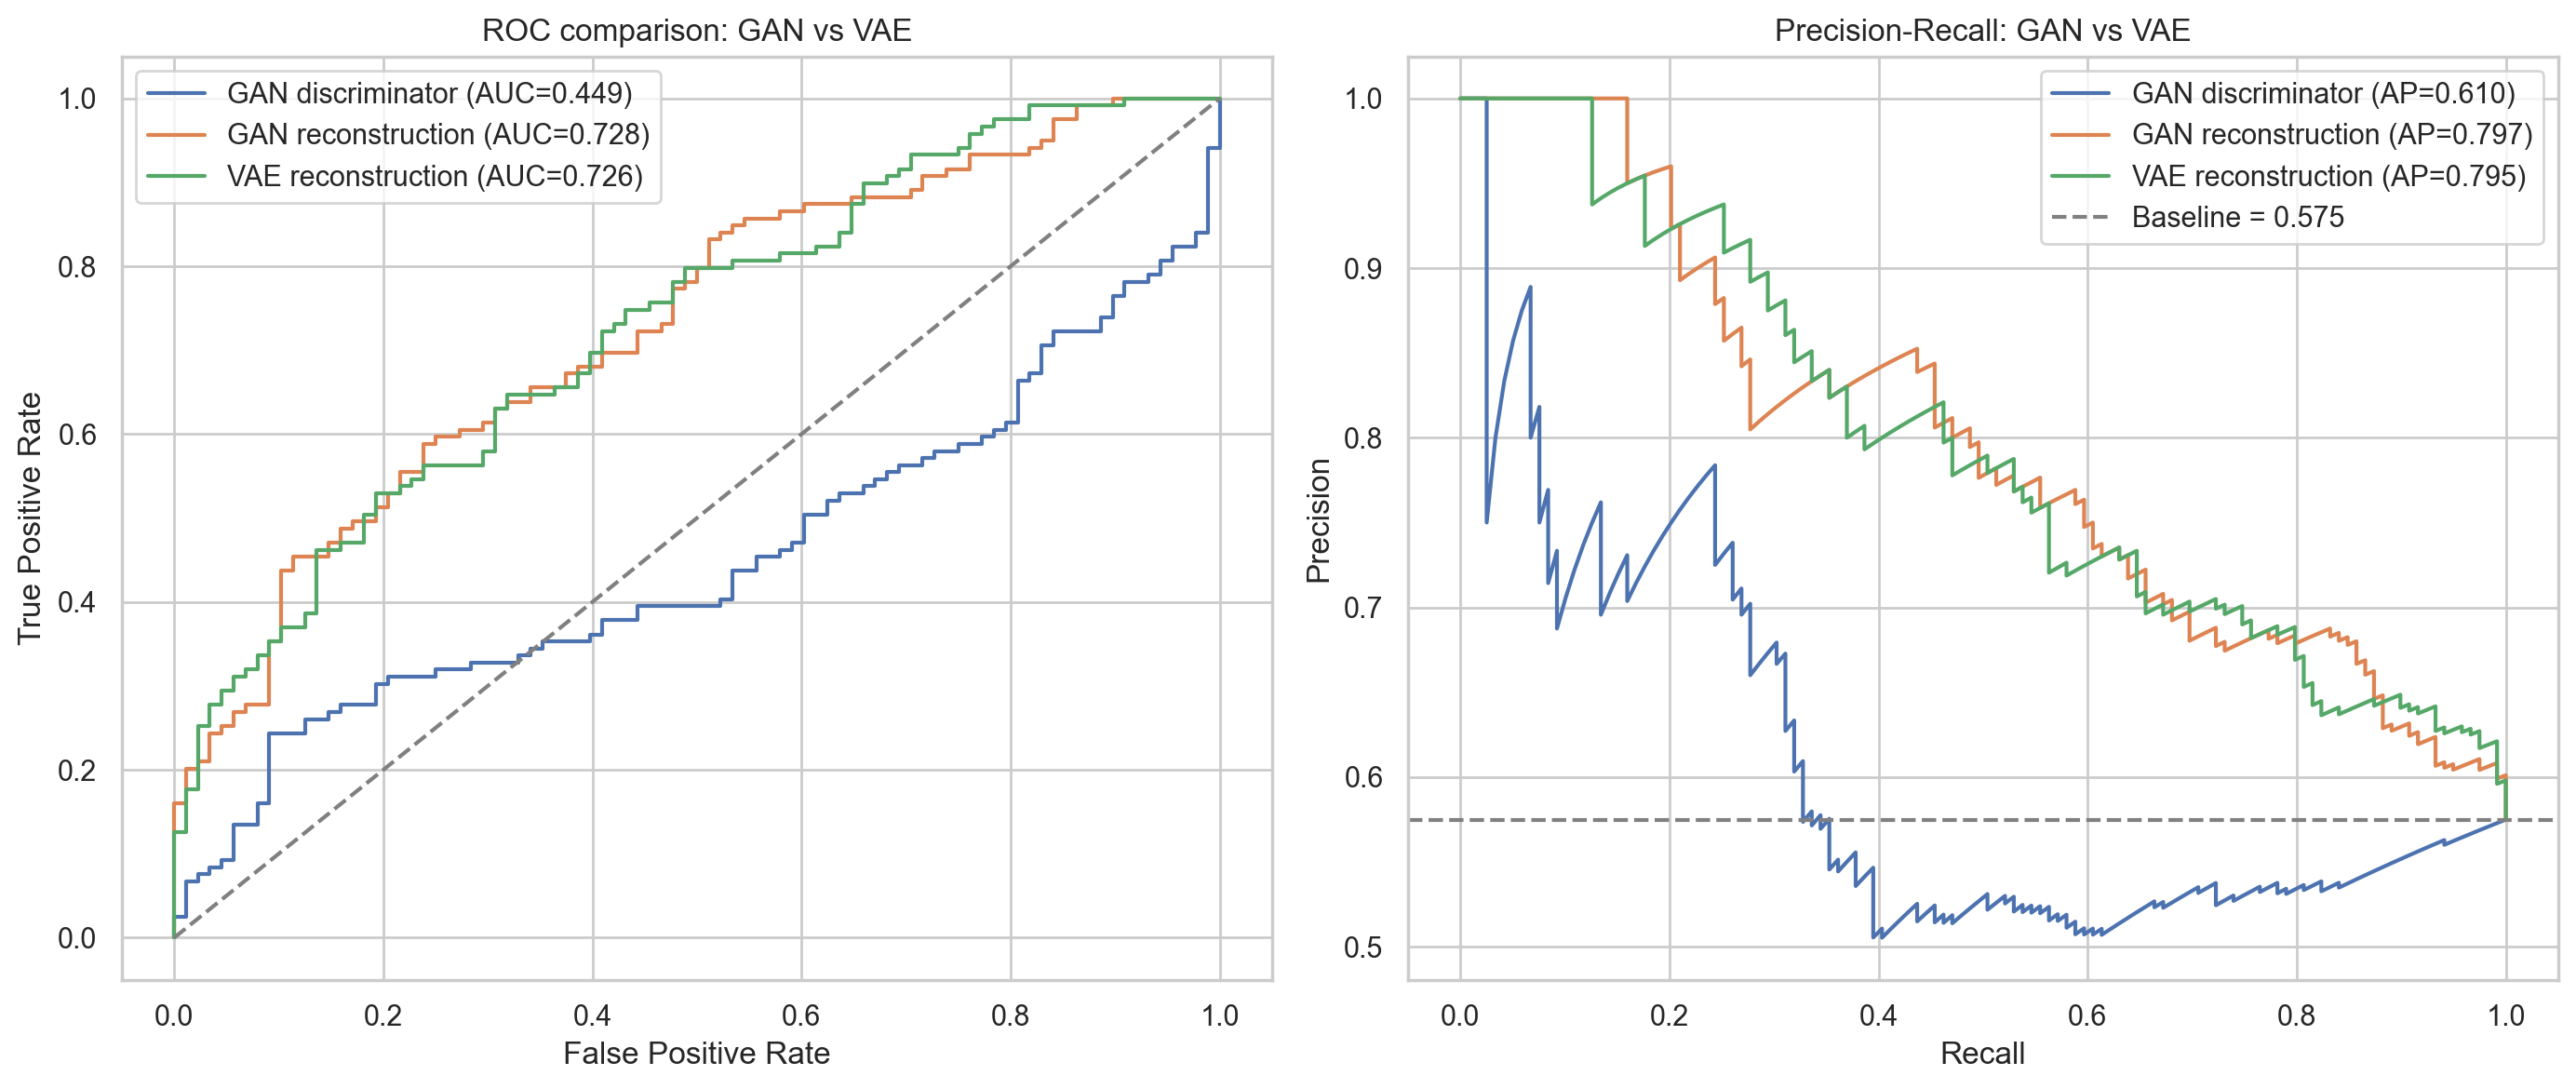

In [96]:
comparison_df = pd.DataFrame([realism_metrics, reconstruction_metrics, vae_metrics])
comparison_df = comparison_df.sort_values("f2", ascending=False).reset_index(drop=True)
display(comparison_df[["model", "recall", "f2", "fnr", "pr_auc", "precision", "f1", "roc_auc"]])

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, metric in zip(axes, ["recall", "f2", "precision", "pr_auc"]):
    sns.barplot(data=comparison_df, x=metric, y="model", ax=ax, palette="viridis")
    ax.set_xlim(0, 1)
    ax.set_title(metric.upper())
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

score_panels = [
    ("GAN discriminator", test_realism),
    ("GAN reconstruction", test_reconstruction_error),
    ("VAE reconstruction", test_vae_error),
]
baseline_rate = float(np.mean(y_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for label, score in score_panels:
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc(fpr, tpr):.3f})")
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, score)
    axes[1].plot(pr_recall, pr_precision, label=f"{label} (AP={average_precision_score(y_test, score):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC comparison: GAN vs VAE")
axes[0].legend()

axes[1].axhline(baseline_rate, color="gray", linestyle="--", label=f"Baseline = {baseline_rate:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall: GAN vs VAE")
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Visual diagnostics and risk-managed equity curve

Two diagnostics close the loop on the risk-management framing:

1. **Score histograms** -- do anomalies sit clearly above the F2-selected threshold?
2. **Full-history risk-managed equity curve** -- we score *every* row in the original
   chronological series with each trained detector and simulate going to cash whenever
   the detector fires. The buy-and-hold line is then a faithful MXUS path over the
   whole window rather than a stress-skewed subsample. The shaded band marks the dates
   that fell into the held-out test set (the only fully out-of-sample slice); rows
   outside the band were used somewhere in train or CV, so their predictions are
   in-sample and should be interpreted accordingly. We also report per-window drawdown
   restricted to the held-out test dates so the headline number is honest.


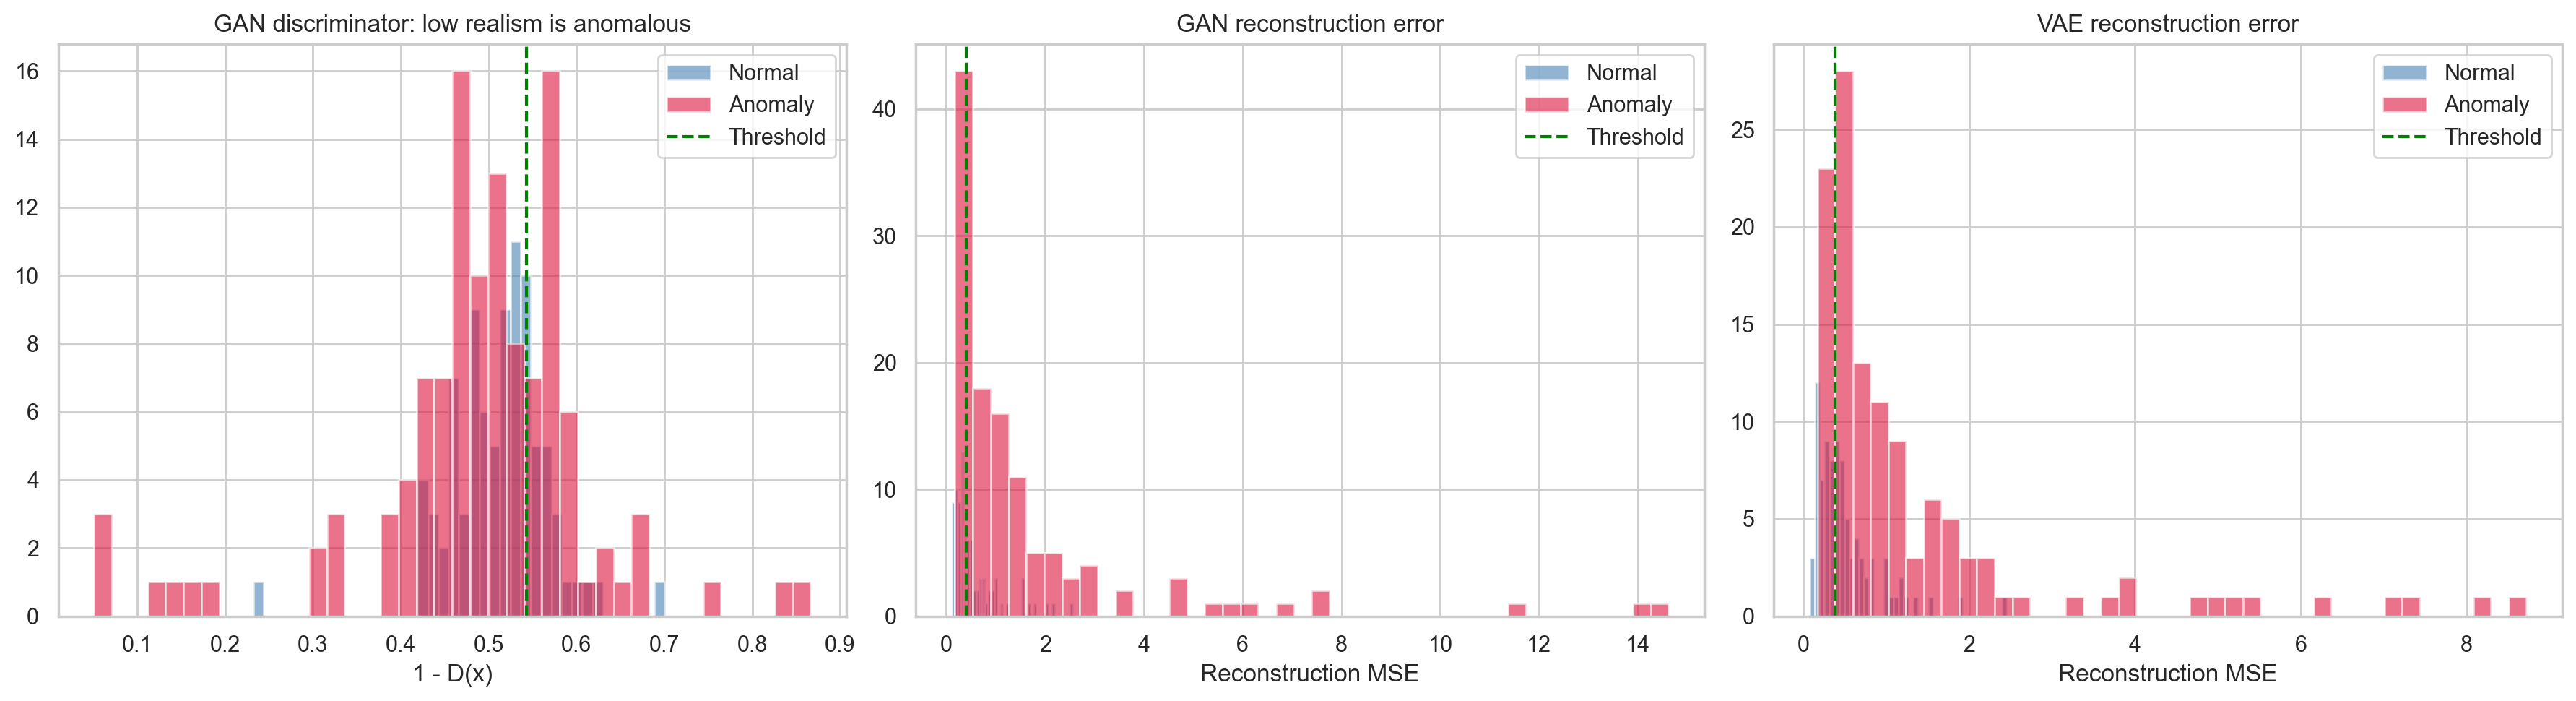

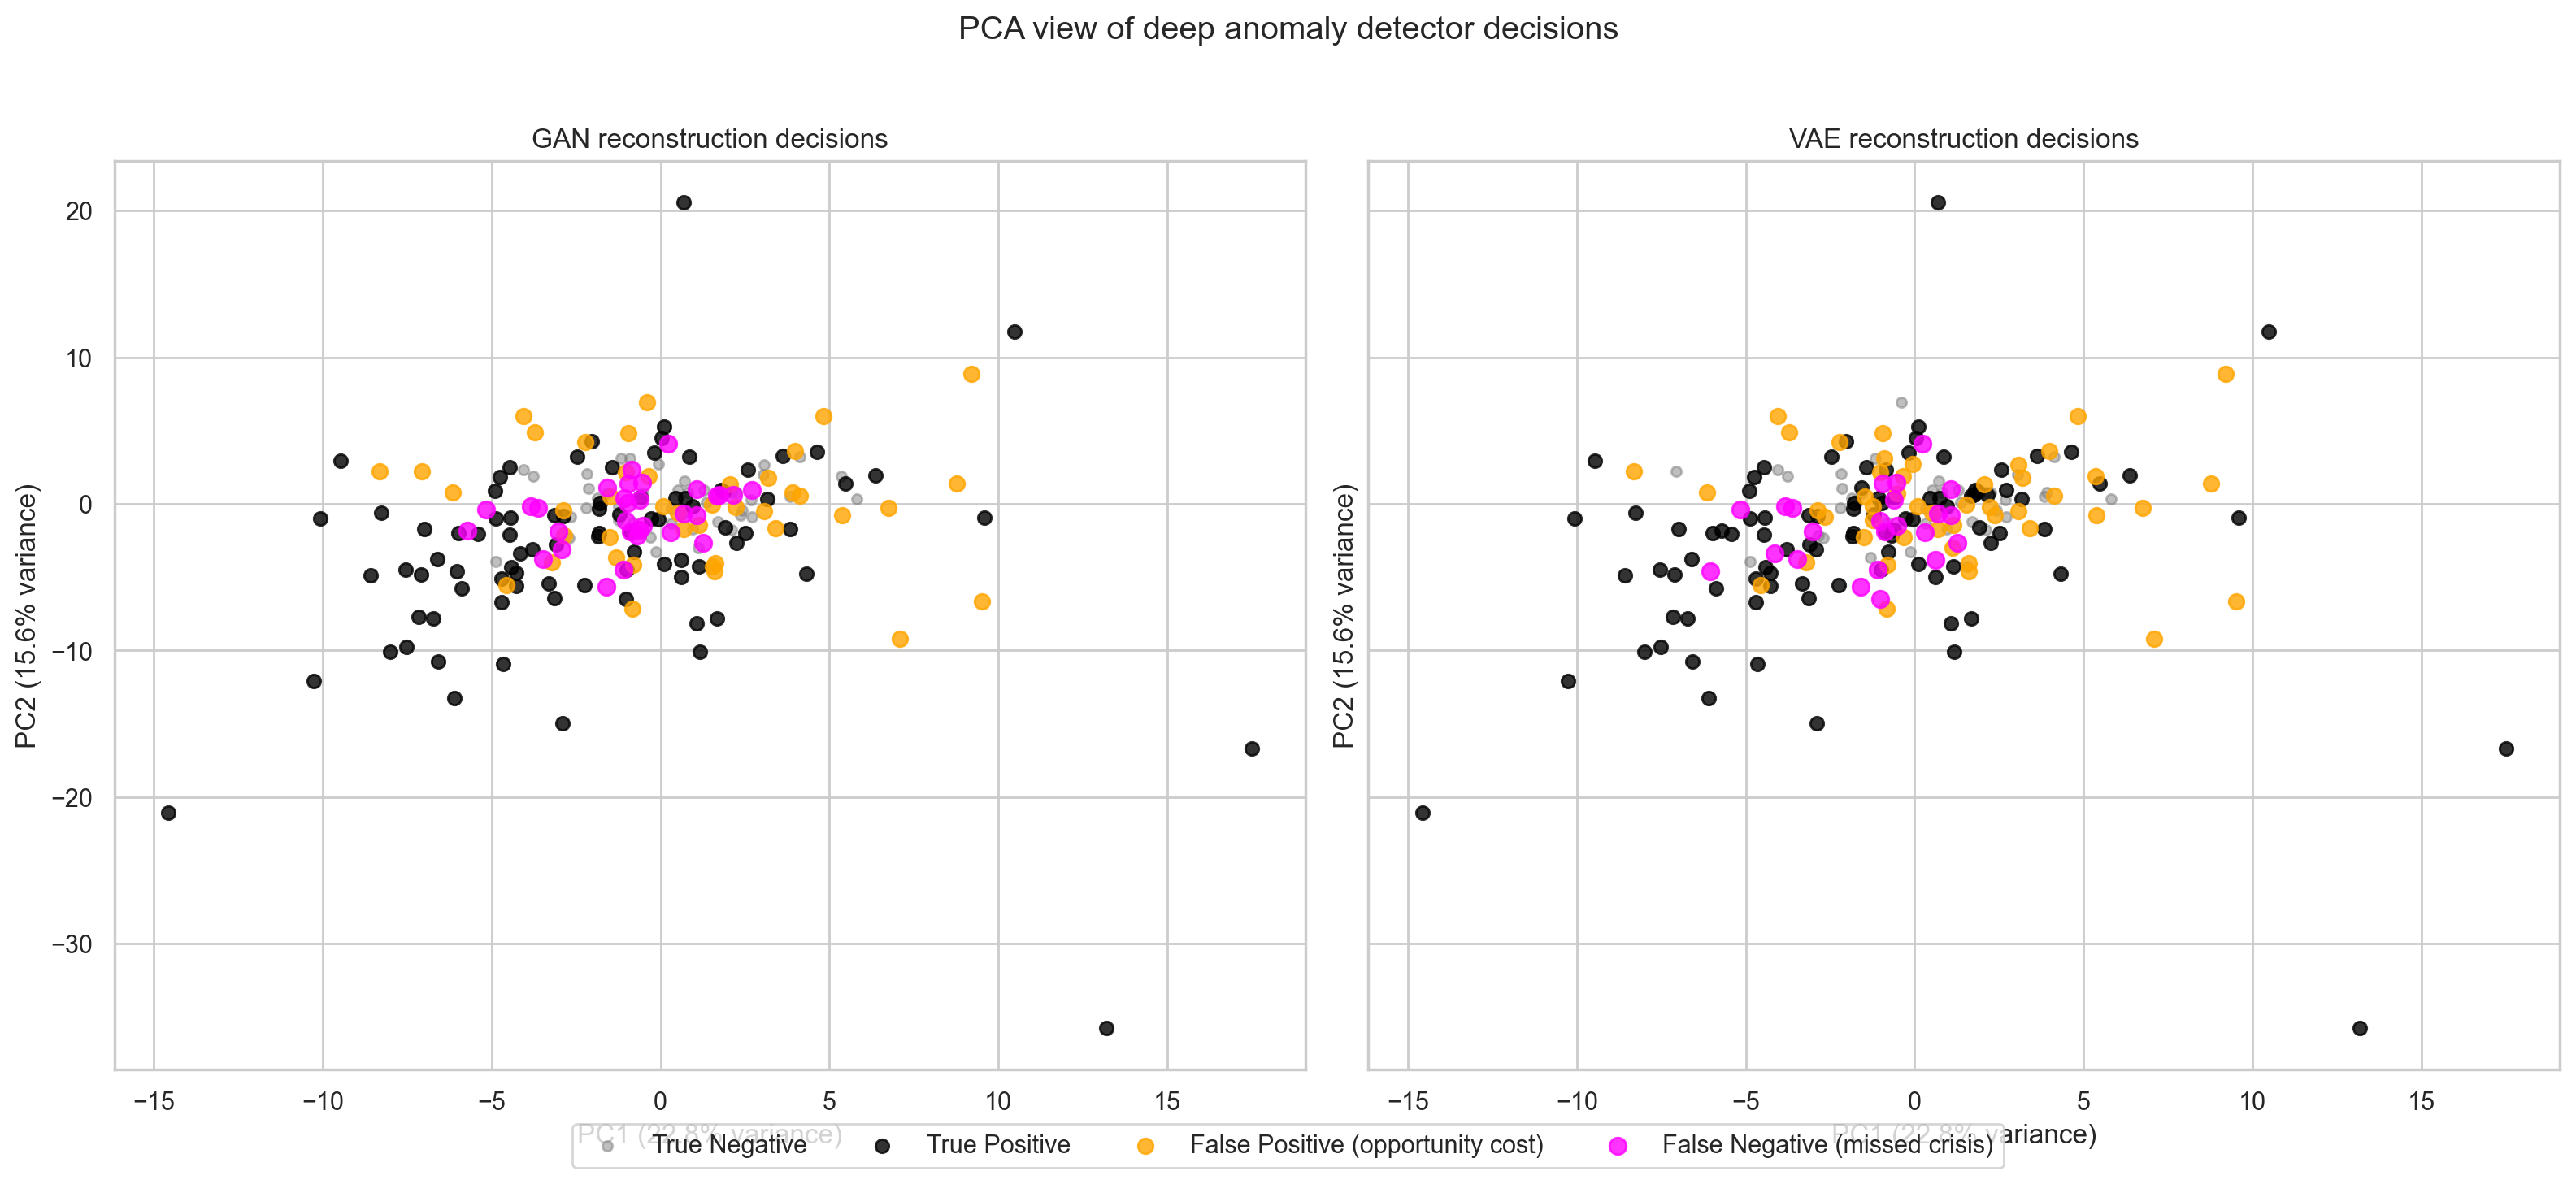

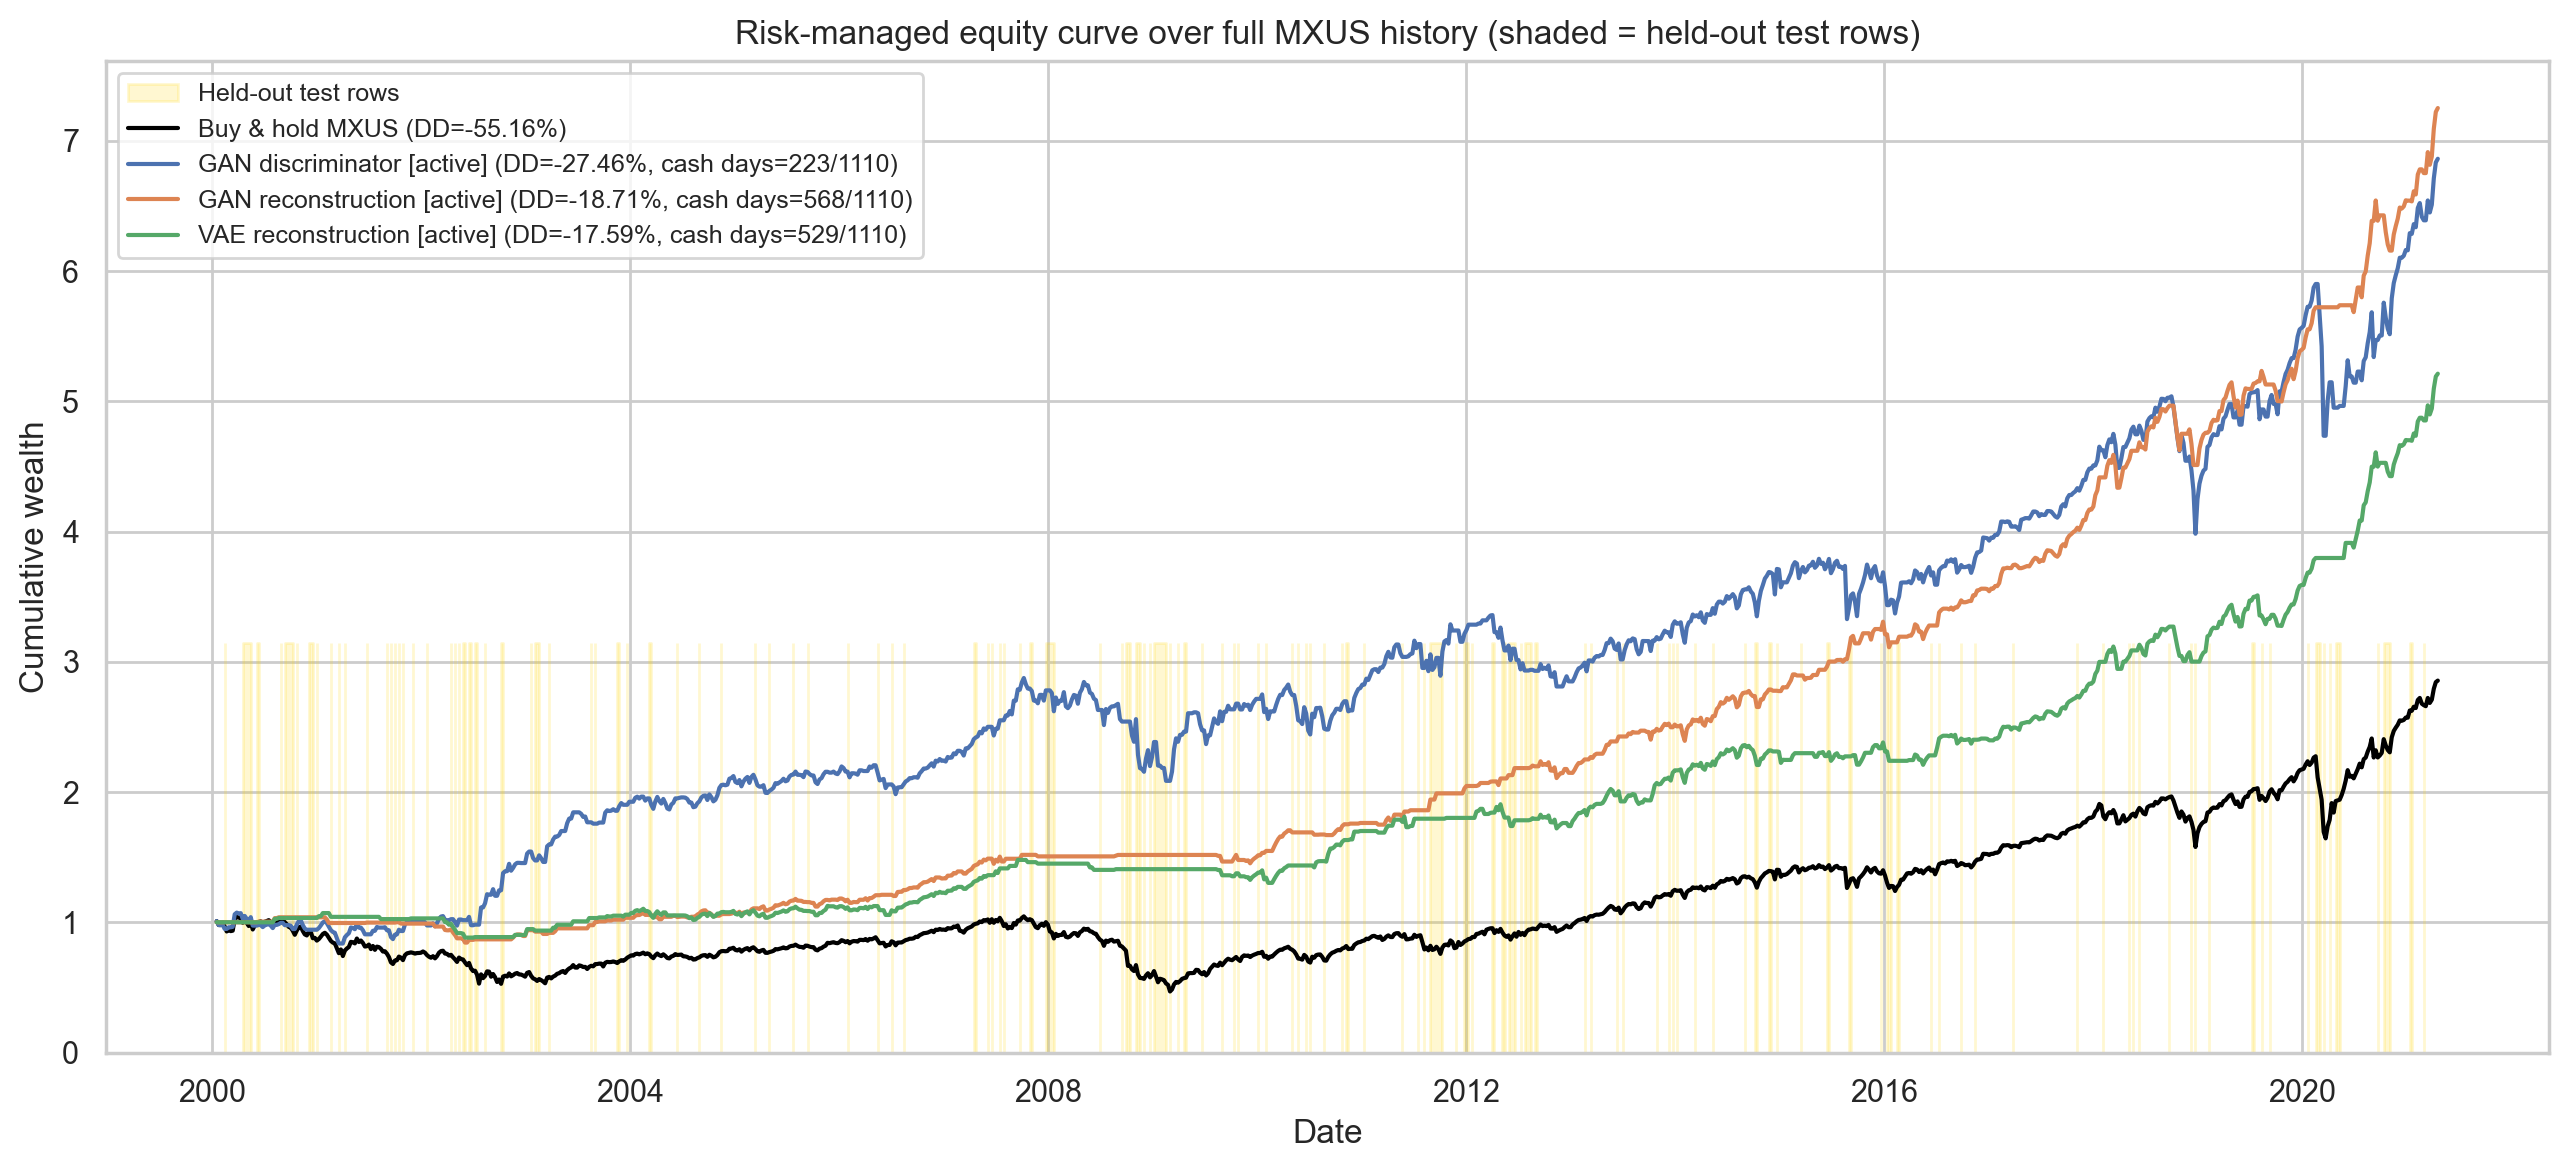


Drawdown comparison. The out-of-sample number is max_drawdown_test_window.


,model,final_wealth,max_drawdown,max_drawdown_test_window,days_in_cash_total,days_in_cash_test,status
0,Buy & hold MXUS,2.855471,-0.551634,-0.546660,0,0,passive baseline
1,GAN discriminator,6.861985,-0.274639,-0.253576,223,62,active
2,GAN reconstruction,7.251317,-0.187069,-0.187069,568,129,active
3,VAE reconstruction,5.211841,-0.175905,-0.152891,529,143,active


In [97]:
score_panels = [
    (test_realism, realism_threshold["epsilon"], "GAN discriminator: low realism is anomalous", "1 - D(x)"),
    (test_reconstruction_error, reconstruction_threshold["epsilon"], "GAN reconstruction error", "Reconstruction MSE"),
    (test_vae_error, vae_threshold["epsilon"], "VAE reconstruction error", "Reconstruction MSE"),
]

fig, axes = plt.subplots(1, len(score_panels), figsize=(6 * len(score_panels), 5))
for ax, (score, threshold, title, xlabel) in zip(axes, score_panels):
    ax.hist(score[y_test == 0], bins=40, alpha=0.6, label="Normal", color="steelblue")
    ax.hist(score[y_test == 1], bins=40, alpha=0.6, label="Anomaly", color="crimson")
    ax.axvline(threshold, color="green", linestyle="--", label="Threshold")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=2, random_state=SEED)
pca.fit(X_train)
X_test_pca = pca.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

def plot_pca_decisions(ax, y_pred, title):
    groups = [
        ((y_test == 0) & (y_pred == 0), "gray", 20, 0.5, "True Negative"),
        ((y_test == 1) & (y_pred == 1), "black", 35, 0.8, "True Positive"),
        ((y_test == 0) & (y_pred == 1), "orange", 45, 0.8, "False Positive (opportunity cost)"),
        ((y_test == 1) & (y_pred == 0), "magenta", 55, 0.8, "False Negative (missed crisis)"),
    ]
    for mask, color, size, alpha, label in groups:
        ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                   c=color, s=size, alpha=alpha, label=label)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

plot_pca_decisions(axes[0], y_pred_reconstruction, "GAN reconstruction decisions")
plot_pca_decisions(axes[1], y_pred_vae, "VAE reconstruction decisions")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)
fig.suptitle("PCA view of deep anomaly detector decisions", y=1.02)
plt.tight_layout()
plt.show()


def max_drawdown(wealth):
    wealth = np.asarray(wealth)
    if wealth.size == 0:
        return 0.0
    running_max = np.maximum.accumulate(wealth)
    return float(((wealth - running_max) / running_max).min())


# Full-chronology risk-managed equity curve. Test rows are highlighted; the test-window
# drawdown column is the only fully out-of-sample number.
if "MXUS" in stationary_df.columns:
    X_all_scaled = scaler.transform(stationary_df.values)
    all_dates = stationary_df.index  # DatetimeIndex
    bench_full = stationary_df["MXUS"].to_numpy()
    buyhold_wealth = np.exp(np.cumsum(bench_full))

    # Robust test-row mask via DatetimeIndex.isin (works regardless of internal dtype).
    test_idx = pd.DatetimeIndex(test_dates)
    test_mask_full = all_dates.isin(test_idx)
    assert test_mask_full.sum() == len(test_idx), (
        f"Test-row mask alignment failed: {test_mask_full.sum()} matched vs {len(test_idx)} expected."
    )

    detectors = [
        ("GAN discriminator",
         discriminator_anomaly_score(D, X_all_scaled),
         realism_threshold["epsilon"],
         realism_threshold.get("never_fires", False)),
        ("GAN reconstruction",
         gan_reconstruction_error(G, X_all_scaled, latent_dim, steps=250),
         reconstruction_threshold["epsilon"],
         reconstruction_threshold.get("never_fires", False)),
        ("VAE reconstruction",
         vae_reconstruction_error(vae_model, X_all_scaled),
         vae_threshold["epsilon"],
         vae_threshold.get("never_fires", False)),
    ]

    plt.figure(figsize=(13, 6))
    ymax = max(buyhold_wealth.max() * 1.1, 1.5)
    plt.fill_between(all_dates, 0, ymax, where=test_mask_full,
                     color="gold", alpha=0.18, step="post", label="Held-out test rows")
    plt.plot(all_dates, buyhold_wealth, color="black", linewidth=1.5,
             label=f"Buy & hold MXUS (DD={max_drawdown(buyhold_wealth):.2%})")

    backtests = [{
        "model": "Buy & hold MXUS",
        "final_wealth": float(buyhold_wealth[-1]),
        "max_drawdown": max_drawdown(buyhold_wealth),
        "max_drawdown_test_window": max_drawdown(buyhold_wealth[test_mask_full]),
        "days_in_cash_total": 0,
        "days_in_cash_test": 0,
        "status": "passive baseline",
    }]

    for label, score_full, epsilon, never_fires in detectors:
        y_pred_full = (score_full > epsilon).astype(int)
        managed_ret = np.where(y_pred_full == 1, 0.0, bench_full)
        managed_wealth = np.exp(np.cumsum(managed_ret))
        status = "unfit (never fires)" if never_fires else "active"
        plt.plot(all_dates, managed_wealth,
                 label=f"{label} [{status}] (DD={max_drawdown(managed_wealth):.2%}, "
                       f"cash days={int(y_pred_full.sum())}/{len(y_pred_full)})")
        backtests.append({
            "model": label,
            "final_wealth": float(managed_wealth[-1]),
            "max_drawdown": max_drawdown(managed_wealth),
            "max_drawdown_test_window": max_drawdown(managed_wealth[test_mask_full]),
            "days_in_cash_total": int(y_pred_full.sum()),
            "days_in_cash_test": int(y_pred_full[test_mask_full].sum()),
            "status": status,
        })

    plt.title("Risk-managed equity curve over full MXUS history "
              "(shaded = held-out test rows)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative wealth")
    plt.ylim(bottom=0)
    plt.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

    backtest_df = pd.DataFrame(backtests)
    print("\nDrawdown comparison. The out-of-sample number is max_drawdown_test_window.")
    display(backtest_df)
else:
    print("MXUS not available -- skipping risk-managed equity-curve backtest.")


## 10. Notes and next steps for the risk-management deployment

This notebook trains and evaluates three deep novelty detectors with a risk-management
lens: missed crises are expensive, defensive false alarms are not, but a degenerate
"always defensive" detector helps nobody.

Operating principles baked into the code:

1. Thresholds are tuned on the cross-validation set by maximising **F2 subject to a
   precision floor** of `max(0.3, 2 * base_rate)`. Without the floor F-beta with
   `beta = 2` collapses into "fire on every row"; the floor keeps the search inside
   a region where the signal is informative.
2. Headline metrics are **recall, F2, FNR, PR-AUC** -- precision/F1/ROC-AUC are
   reported for continuity but not used to rank models.
3. The risk-managed equity-curve backtest in section 9 runs over the **full MXUS
   history**; the buy-and-hold path is therefore the real MXUS path, not a
   subsample. The held-out test window is shaded in yellow, and the table reports a
   separate `max_drawdown_test_window` which is the only fully out-of-sample number.

Practical caveats:

- Rows outside the shaded test window are in-sample for the detector (the GAN/VAE
  were trained on their normal portion). The full-history curve illustrates behaviour
  but production decisions should rely on the test-window drawdown column.
- Production deployment should additionally use a **chronological walk-forward
  split** (train on past, validate on rolling future windows) rather than the random
  shuffle used here.
- GANs and VAEs are unstable on tabular financial data. Re-run with several seeds
  and inspect both the F2/PR-AUC tables and the equity-curve plot before committing
  to a single detector.
- The precision floor is the main lever for trading off recall vs turnover. Tightening
  the floor pushes the model toward fewer, higher-conviction risk-off calls.
